#  Prédiction de l'Âge Biologique par Méthylation de l'ADN


#### **Auteurs :** 

### Don De Dieu Mboumba & Moustapha Diago & Baba Galle Ndiaye

#### **Master 1 Mathématiques Appliquées, Statistiques UCA 2025-2026**

### Sujet proposé par Sylvain Moinard, CHU de Clermont-Ferrand

#### **Objectif :**

 construire un modèle prédictif de l’âge (chronologique) à partir de données de méthylation 

(valeurs beta pour une liste de site CpG).

Données : 400 échantillons avec valeurs de méthylation pour 894k sites + covariables (genre, origine ethnique).



#  Configuration : Chemins des fichiers

In [2]:
import os

DOSSIER_DATA = "C:/Users/babag/Desktop/baba/Projet_Data"

PATH_ANNOT    = os.path.join(DOSSIER_DATA, "annot_projet.csv")
PATH_BETA_TOY = os.path.join(DOSSIER_DATA, "beta_50k.csv")

SEUIL_NA_DROP = 0.40
SEED          = 42

for p in [PATH_ANNOT, PATH_BETA_TOY]:
    if os.path.exists(p):
        print(f"   {os.path.basename(p)}")
    else:
        print(f"   INTROUVABLE : {p}")
print(" Configuration OK")
print(f"   Dossier : {os.path.abspath(DOSSIER_DATA)}")

   annot_projet.csv
   beta_50k.csv
 Configuration OK
   Dossier : C:\Users\babag\Desktop\baba\Projet_Data


#  Imports

In [3]:

import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

# Sklearn
from sklearn.linear_model   import RidgeCV, LassoCV, ElasticNetCV
from sklearn.svm             import SVR
from sklearn.ensemble        import (RandomForestRegressor,
                                     StackingRegressor,
                                     GradientBoostingRegressor)
from sklearn.neural_network  import MLPRegressor
from sklearn.decomposition   import PCA
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics         import (mean_absolute_error,
                                     mean_squared_error, r2_score)
from sklearn.pipeline        import make_pipeline
from sklearn.impute          import SimpleImputer

# Boosting
import xgboost  as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings('ignore')
np.random.seed(SEED)

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False
})
COLORS = ['#2C7BB6','#D7191C','#1A9641','#FDAE61',
          '#7B2D8B','#888780','#F0997B','#5DCAA5','#AFA9EC','#D4537E']

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 100
PALETTE = {"primary":"#028090","secondary":"#02C39A",
           "warn":"#F96167","neutral":"#36454F"}

print(" Imports OK")


 Imports OK



# Partie I : Chargement des données

In [4]:
# Annotations 
annot_df = pd.read_csv(PATH_ANNOT)

# Matrice beta brute : lignes = CpG, colonnes = sujets
beta_df = pd.read_csv(PATH_BETA_TOY, index_col=0)

print(f"annot_df : {annot_df.shape[0]} sujets × {annot_df.shape[1]} variables")
print(f"beta_df  : {beta_df.shape[0]:,} CpG × {beta_df.shape[1]} sujets  (avant nettoyage)")
display(annot_df.head(3))


annot_df : 400 sujets × 5 variables
beta_df  : 50,000 CpG × 400 sujets  (avant nettoyage)


,Sample_Name,female,ethnicity,age,Sample_description
0,GSM7866964,False,White,31.35,207700470022_R08C01
1,GSM7866965,True,Asian,79.45,207686150104_R02C01
2,GSM7866966,False,Asian,60.42,207700460080_R08C01


In [5]:
cpg_cols = beta_df.index.tolist()
print(f"CpG disponibles (avant nettoyage) : {len(cpg_cols):,}")
print(f"Sujets disponibles                : {beta_df.shape[1]}")


CpG disponibles (avant nettoyage) : 50,000
Sujets disponibles                : 400


# Partie II : Analyse Exploratoire des Données
## II.1 Distribution de l'âge chronologique

,Statistique,Valeur
0,Moyenne,52.95 ans
1,Médiane,53.55 ans
2,Écart-type,21.24 ans
3,Min,18.09 ans
4,Max,90.00 ans
5,Q1 (25%),34.00 ans
6,Q3 (75%),72.17 ans
7,Étendue,71.91 ans
8,Asymétrie,0.003


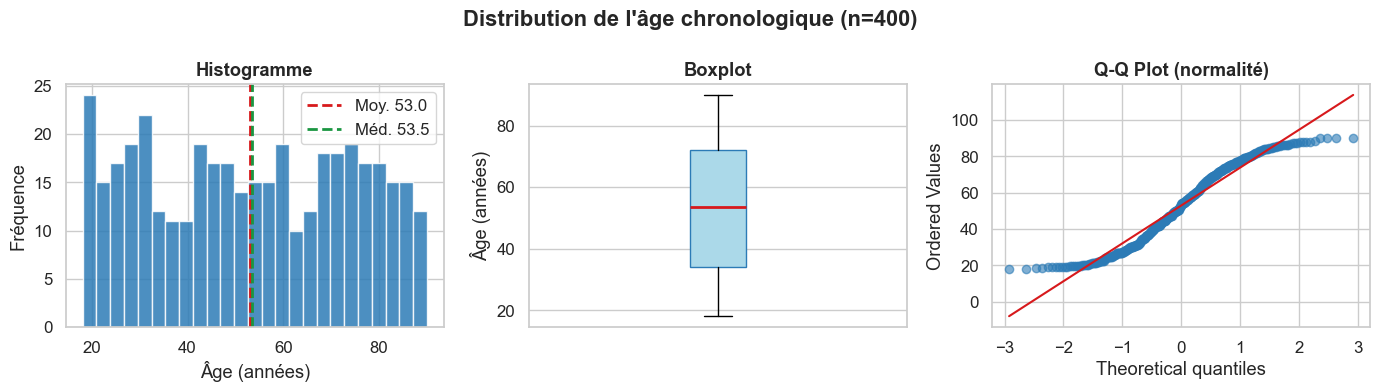

In [6]:
age = annot_df['age']

stats_age = pd.DataFrame({
    'Statistique': ['Moyenne','Médiane','Écart-type','Min','Max',
                    'Q1 (25%)','Q3 (75%)','Étendue','Asymétrie'],
    'Valeur': [
        f"{age.mean():.2f} ans", f"{age.median():.2f} ans",
        f"{age.std():.2f} ans",  f"{age.min():.2f} ans",
        f"{age.max():.2f} ans",  f"{age.quantile(.25):.2f} ans",
        f"{age.quantile(.75):.2f} ans",
        f"{age.max()-age.min():.2f} ans",
        f"{stats.skew(age):.3f}"
    ]
})
display(stats_age.style.set_caption("Statistiques descriptives — Âge"))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Distribution de l'âge chronologique (n=400)", fontweight='bold')

axes[0].hist(age, bins=25, color=COLORS[0], edgecolor='white', alpha=0.85)
axes[0].axvline(age.mean(),   color=COLORS[1], lw=2, ls='--',
                label=f'Moy. {age.mean():.1f}')
axes[0].axvline(age.median(), color=COLORS[2], lw=2, ls='--',
                label=f'Méd. {age.median():.1f}')
axes[0].set_xlabel('Âge (années)'); axes[0].set_ylabel('Fréquence')
axes[0].set_title('Histogramme'); axes[0].legend()

axes[1].boxplot(age, patch_artist=True,
                boxprops=dict(facecolor='#ABD9E9', color=COLORS[0]),
                medianprops=dict(color=COLORS[1], lw=2))
axes[1].set_ylabel('Âge (années)'); axes[1].set_title('Boxplot')
axes[1].set_xticks([])

stats.probplot(age, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot (normalité)')
axes[2].get_lines()[0].set(color=COLORS[0], alpha=0.6)
axes[2].get_lines()[1].set(color=COLORS[1])

plt.tight_layout(); plt.show()


## II.2 Distribution de l'âge selon le sexe et l'ethnie

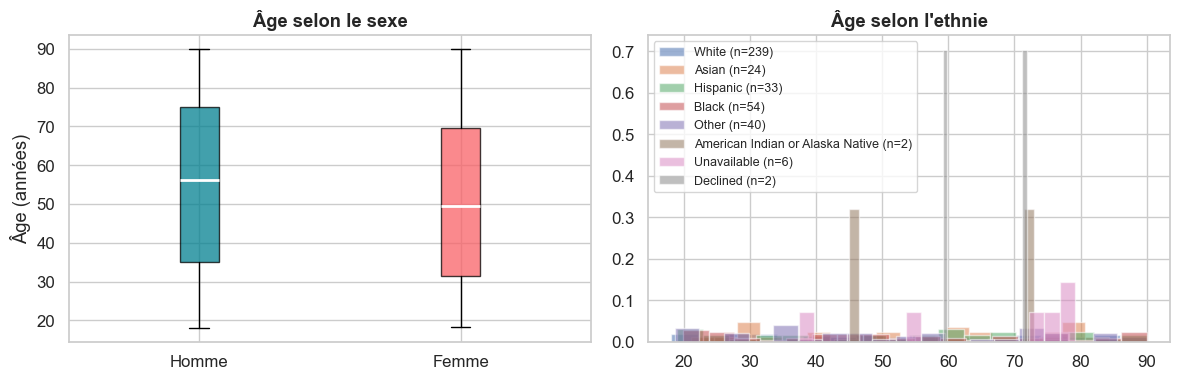

In [7]:
# Stratification par sexe et ethnie
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
groups = {}
female_str = annot_df["female"].astype(str)
for v in female_str.unique():
    lbl = "Femme" if v in ["1","True","1.0"] else "Homme"
    groups[lbl] = age[female_str == v].dropna().values
axes[0].boxplot(list(groups.values()), patch_artist=True,
                labels=list(groups.keys()),
                medianprops=dict(color="white", linewidth=2))
for i, (l, d) in enumerate(groups.items()):
    axes[0].patches[i].set_facecolor([PALETTE["primary"],PALETTE["warn"]][i])
    axes[0].patches[i].set_alpha(0.75)
axes[0].set_title("Âge selon le sexe"); axes[0].set_ylabel("Âge (années)")

for eth in annot_df["ethnicity"].unique():
    s = age[annot_df["ethnicity"] == eth].dropna()
    axes[1].hist(s, bins=18, alpha=0.55, label=f"{eth} (n={len(s)})", density=True)
axes[1].set_title("Âge selon l'ethnie"); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

## II.3 Analyse des valeurs manquantes

> **Stratégie en 4 étapes (méthode horloge_v4.Rmd) :**
>
> 1. Valeurs hors [0, 1] → NA
> 2. Supprimer les **sujets** qui ont plus de 50% NA
> 3. Supprimer les **CpG** qui ont plus de 20% NA
> 4. Filtrage par **variance** (bas 10e percentile)
> 5. Imputer les NA restants par la **médiane de chaque CpG**

In [8]:
# Analyse sur la matrice BRUTE : lignes=CpG, colonnes=sujets
na_par_cpg_pct   = beta_df.isnull().mean(axis=1) * 100
na_par_sujet_pct = beta_df.isnull().mean(axis=0) * 100

na_total      = beta_df.isnull().sum().sum()
na_pct_global = na_total / beta_df.size * 100

print("═" * 55)
print("DIAGNOSTIC DES VALEURS MANQUANTES — beta_df brut")
print("═" * 55)
print(f"Matrice            : {beta_df.shape[0]:,} CpG × {beta_df.shape[1]} sujets")
print(f"NA totaux          : {na_total:,}")
print(f"% NA global        : {na_pct_global:.2f}%")
print()
print("--- PAR CpG (lignes) ---")
print(f"CpG sans NA               : {(na_par_cpg_pct == 0).sum():,}")
print(f"CpG avec NA > 20% → DROP  : {(na_par_cpg_pct > 20).sum():,}")
print(f"CpG avec NA > 50%         : {(na_par_cpg_pct > 50).sum():,}")
print()
print("--- PAR SUJET (colonnes) ---")
print(f"Sujets avec NA > 10%       : {(na_par_sujet_pct > 10).sum()}")
print(f"Sujets avec NA > 50% → DROP: {(na_par_sujet_pct > 50).sum()}")
print()
print("Top 5 sujets les plus dégradés :")
for s, v in na_par_sujet_pct.nlargest(5).items():
    print(f"  {str(s)[:30]:30s} : {v:.1f}% NA")


═══════════════════════════════════════════════════════
DIAGNOSTIC DES VALEURS MANQUANTES — beta_df brut
═══════════════════════════════════════════════════════
Matrice            : 50,000 CpG × 400 sujets
NA totaux          : 2,132,591
% NA global        : 10.66%

--- PAR CpG (lignes) ---
CpG sans NA               : 1,469
CpG avec NA > 20% → DROP  : 6,942
CpG avec NA > 50%         : 4,526

--- PAR SUJET (colonnes) ---
Sujets avec NA > 10%       : 176
Sujets avec NA > 50% → DROP: 3

Top 5 sujets les plus dégradés :
  207700470022_R01C01            : 75.5% NA
  207700470029_R03C01            : 68.5% NA
  207686150104_R06C01            : 54.4% NA
  207805820127_R08C01            : 41.5% NA
  207700460010_R06C01            : 41.4% NA


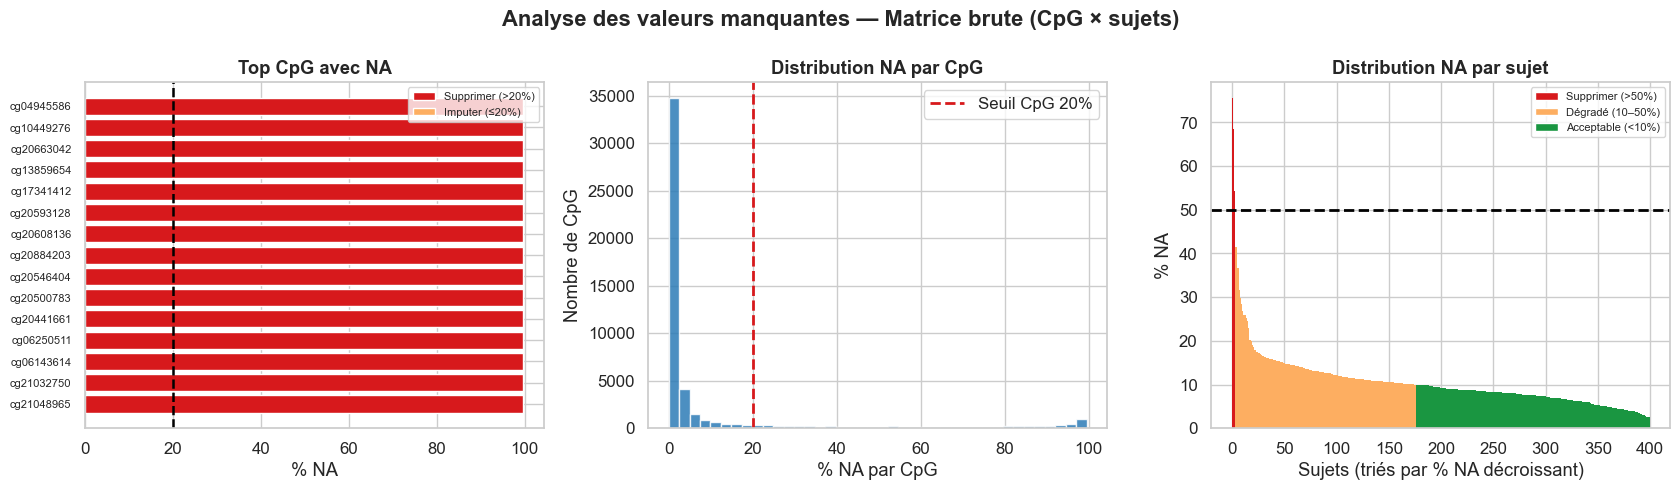

In [9]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Analyse des valeurs manquantes — Matrice brute (CpG × sujets)',
             fontweight='bold')

# Graphe 1 : Top CpG avec NA
na_with_missing = na_par_cpg_pct[na_par_cpg_pct > 0].sort_values(ascending=False)
top_na = na_with_missing.head(15) if len(na_with_missing) > 30 else na_with_missing
colors_cpg = ['#D7191C' if p > 20 else '#FDAE61' for p in top_na.values]
axes[0].barh(range(len(top_na)), top_na.values[::-1],
             color=colors_cpg[::-1], edgecolor='white')
axes[0].set_yticks(range(len(top_na)))
axes[0].set_yticklabels(top_na.index[::-1], fontsize=8)
axes[0].axvline(20, color='black', ls='--', lw=1.8)
axes[0].set_xlabel('% NA'); axes[0].set_title('Top CpG avec NA')
legend_el = [Patch(facecolor='#D7191C', label='Supprimer (>20%)'),
              Patch(facecolor='#FDAE61', label='Imputer (≤20%)')]
axes[0].legend(handles=legend_el, fontsize=8)

# Graphe 2 : Distribution NA par CpG
axes[1].hist(na_par_cpg_pct, bins=40, color=COLORS[0],
             edgecolor='white', alpha=0.85)
axes[1].axvline(20, color=COLORS[1], ls='--', lw=2, label='Seuil CpG 20%')
axes[1].set_xlabel('% NA par CpG'); axes[1].set_ylabel('Nombre de CpG')
axes[1].set_title('Distribution NA par CpG'); axes[1].legend()

# Graphe 3 : Distribution NA par sujet
colors_suj = ['#D7191C' if v > 50 else '#FDAE61' if v > 10 else COLORS[2]
              for v in na_par_sujet_pct.values]
axes[2].bar(range(len(na_par_sujet_pct)),
            sorted(na_par_sujet_pct.values, reverse=True),
            color=sorted(colors_suj,
                         key=lambda c: {COLORS[2]:0,'#FDAE61':1,'#D7191C':2}[c],
                         reverse=True),
            width=1.0, edgecolor='none')
axes[2].axhline(50, color='black', ls='--', lw=2, label='Seuil sujet 50%')
axes[2].set_xlabel('Sujets (triés par % NA décroissant)')
axes[2].set_ylabel('% NA'); axes[2].set_title('Distribution NA par sujet')
legend_suj = [Patch(facecolor='#D7191C', label='Supprimer (>50%)'),
               Patch(facecolor='#FDAE61', label='Dégradé (10–50%)'),
               Patch(facecolor=COLORS[2],  label='Acceptable (<10%)')]
axes[2].legend(handles=legend_suj, fontsize=8)

plt.tight_layout(); plt.show()


## II.4 Corrélations CpG  avec l'Âge

In [10]:
def safe_corr(x, y):
    """Corrélation de Pearson avec suppression pairwise des NA."""
    mask = ~(np.isnan(x) | np.isnan(y))
    if mask.sum() < 3:
        return np.nan, np.nan
    return stats.pearsonr(x[mask], y[mask])

# Alignement par position (identique à horloge_v4.Rmd)
sujets_communs = beta_df.columns.tolist()
annot_aligned  = annot_df.copy()
annot_aligned['chip_id'] = sujets_communs
age_arr        = annot_aligned['age'].values.astype(float)
beta_aligned   = beta_df[sujets_communs]

print(f"Sujets en commun : {len(sujets_communs)}")
print("Calcul des corrélations CpG–âge...")

corr_results = []
for i, cpg in enumerate(beta_aligned.index):
    vals = beta_aligned.loc[cpg].values.astype(float)
    r, p = safe_corr(age_arr, vals)
    corr_results.append({'CpG': cpg, 'correlation': r,
                          'p_value': p, 'abs_corr': abs(r) if not np.isnan(r) else np.nan})
    if (i+1) % 10000 == 0:
        print(f"  {i+1:,} / {len(beta_aligned):,} CpG traités")

corr_df = (pd.DataFrame(corr_results)
             .dropna()
             .sort_values('abs_corr', ascending=False)
             .reset_index(drop=True))

print(f"\nCpG avec corrélation calculable : {len(corr_df):,}")
print(f"CpG avec |r| > 0.3              : {(corr_df['abs_corr']>0.3).sum()}")
print(f"CpG significatifs (p<0.05)       : {(corr_df['p_value']<0.05).sum()}")
display(corr_df.head(10).round(4))


Sujets en commun : 400
Calcul des corrélations CpG–âge...
  10,000 / 50,000 CpG traités
  20,000 / 50,000 CpG traités
  30,000 / 50,000 CpG traités
  40,000 / 50,000 CpG traités
  50,000 / 50,000 CpG traités

CpG avec corrélation calculable : 49,709
CpG avec |r| > 0.3              : 3652
CpG significatifs (p<0.05)       : 22891


,CpG,correlation,p_value,abs_corr
0,cg15800360,-1.0000,0.0027,1.0000
1,cg21909102,0.9999,0.0092,0.9999
2,cg25599101,0.9999,0.0097,0.9999
3,cg00203621,0.9998,0.0141,0.9998
4,cg22598048,-0.9996,0.0178,0.9996
5,cg02525742,-0.9995,0.0208,0.9995
6,cg19303530,0.9990,0.0292,0.9990
7,cg05655221,0.9982,0.0379,0.9982
8,cg00009352,0.9978,0.0418,0.9978
9,cg09331881,-0.9975,0.0449,0.9975


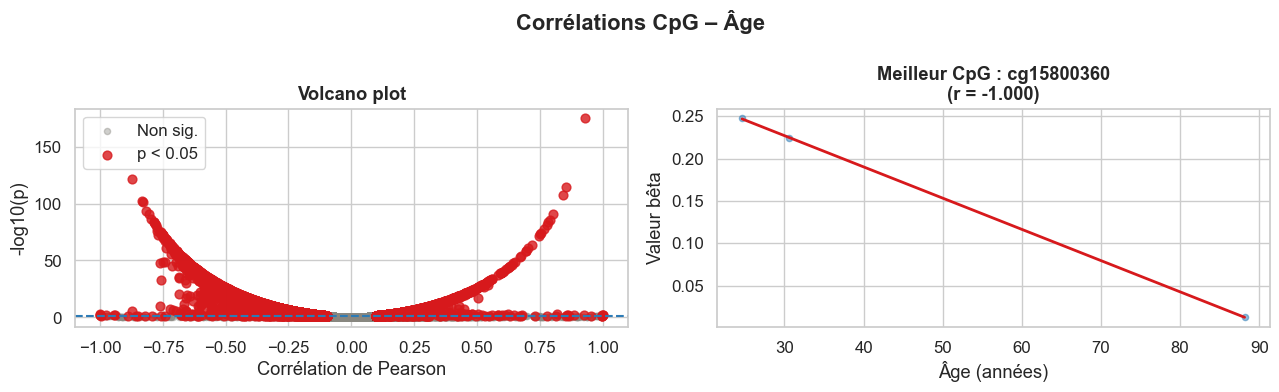

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Corrélations CpG – Âge', fontweight='bold')

sig = corr_df['p_value'] < 0.05
axes[0].scatter(corr_df.loc[~sig,'correlation'],
                -np.log10(corr_df.loc[~sig,'p_value']),
                color='#888780', alpha=0.4, s=20, label='Non sig.')
axes[0].scatter(corr_df.loc[sig,'correlation'],
                -np.log10(corr_df.loc[sig,'p_value']),
                color=COLORS[1], alpha=0.8, s=40, label='p < 0.05')
axes[0].axhline(-np.log10(0.05), color=COLORS[0], ls='--', lw=1.5)
axes[0].set_xlabel('Corrélation de Pearson'); axes[0].set_ylabel('-log10(p)')
axes[0].set_title('Volcano plot'); axes[0].legend()

top_cpg   = corr_df.iloc[0]['CpG']
top_r     = corr_df.iloc[0]['correlation']
cpg_vals  = beta_aligned.loc[top_cpg].values.astype(float)
age_vals  = age_arr.copy()
valid     = ~np.isnan(cpg_vals)
axes[1].scatter(age_vals[valid], cpg_vals[valid],
                color=COLORS[0], alpha=0.5, s=20)
m, b = np.polyfit(age_vals[valid], cpg_vals[valid], 1)
xl = np.linspace(age_vals[valid].min(), age_vals[valid].max(), 100)
axes[1].plot(xl, m*xl+b, color=COLORS[1], lw=2)
axes[1].set_xlabel('Âge (années)'); axes[1].set_ylabel('Valeur bêta')
axes[1].set_title(f'Meilleur CpG : {top_cpg}\n(r = {top_r:.3f})')

plt.tight_layout(); plt.show()


## II.5 ACP 

In [12]:
beta_explo        = beta_df[sujets_communs].copy()
row_medians       = beta_explo.median(axis=1)
beta_explo_filled = beta_explo.T.fillna(row_medians).T
X_explo           = beta_explo_filled.T.values.astype(float)

scaler_explo = StandardScaler()
X_explo_sc   = scaler_explo.fit_transform(X_explo)

n_comp_explo = min(50, X_explo_sc.shape[1], X_explo_sc.shape[0]-1)
pca_explo    = PCA(n_components=n_comp_explo, random_state=SEED)
Z_explo      = pca_explo.fit_transform(X_explo_sc)

cumvar_explo = np.cumsum(pca_explo.explained_variance_ratio_)
K80_explo    = int(np.argmax(cumvar_explo >= 0.80)) + 1

print(f"ACP exploratoire : {X_explo_sc.shape[0]} sujets × {X_explo_sc.shape[1]} CpG")
print(f"Composantes pour 80% de variance : {K80_explo}")
print(f"CP1 : {pca_explo.explained_variance_ratio_[0]*100:.2f}%")
print(f"CP2 : {pca_explo.explained_variance_ratio_[1]*100:.2f}%")


ACP exploratoire : 400 sujets × 50000 CpG
Composantes pour 80% de variance : 1
CP1 : 18.24%
CP2 : 14.07%


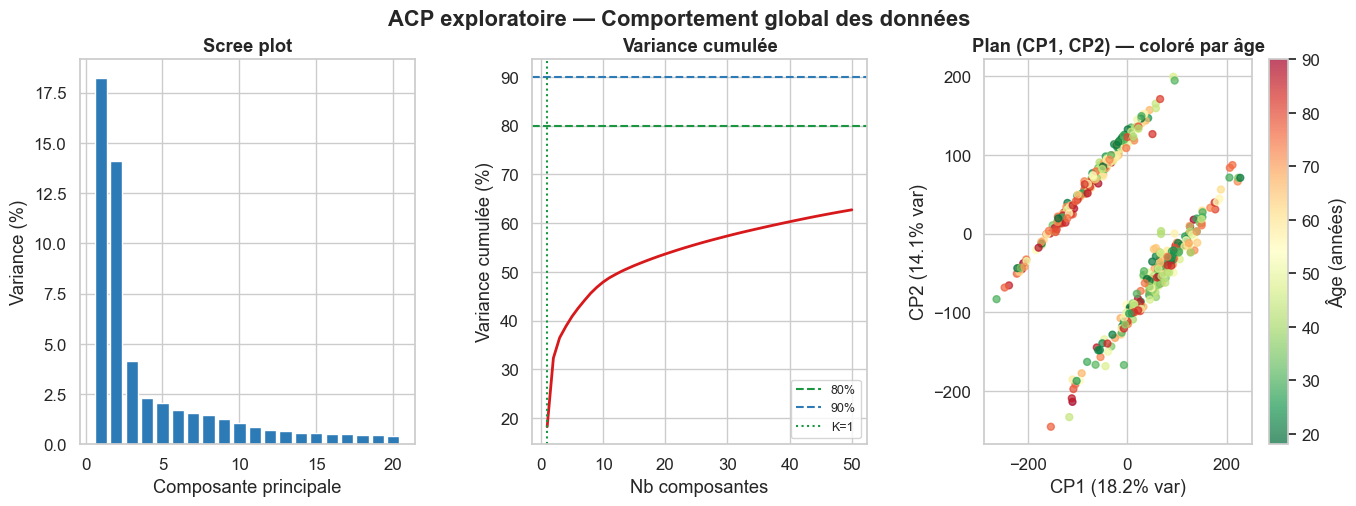

In [13]:
fig = plt.figure(figsize=(16, 5))
fig.suptitle('ACP exploratoire — Comportement global des données', fontweight='bold')
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

n_show = min(20, n_comp_explo)
ax0 = fig.add_subplot(gs[0])
ax0.bar(range(1, n_show+1),
        pca_explo.explained_variance_ratio_[:n_show]*100,
        color=COLORS[0], edgecolor='white')
ax0.set_xlabel('Composante principale'); ax0.set_ylabel('Variance (%)')
ax0.set_title('Scree plot')

ax1 = fig.add_subplot(gs[1])
ax1.plot(range(1, n_comp_explo+1), cumvar_explo*100, color=COLORS[1], lw=2)
ax1.axhline(80, color=COLORS[2], ls='--', lw=1.5, label='80%')
ax1.axhline(90, color=COLORS[0], ls='--', lw=1.5, label='90%')
ax1.axvline(K80_explo, color=COLORS[2], ls=':', lw=1.5, label=f'K={K80_explo}')
ax1.set_xlabel('Nb composantes'); ax1.set_ylabel('Variance cumulée (%)')
ax1.set_title('Variance cumulée'); ax1.legend(fontsize=9)

ax2 = fig.add_subplot(gs[2])
sc = ax2.scatter(Z_explo[:, 0], Z_explo[:, 1],
                  c=age_arr, cmap='RdYlGn_r', alpha=0.7, s=25)
plt.colorbar(sc, ax=ax2, label='Âge (années)')
ax2.set_xlabel(f"CP1 ({pca_explo.explained_variance_ratio_[0]*100:.1f}% var)")
ax2.set_ylabel(f"CP2 ({pca_explo.explained_variance_ratio_[1]*100:.1f}% var)")
ax2.set_title('Plan (CP1, CP2) — coloré par âge')

plt.savefig('fig_acp_exploratoire.png', dpi=150, bbox_inches='tight')
plt.show()


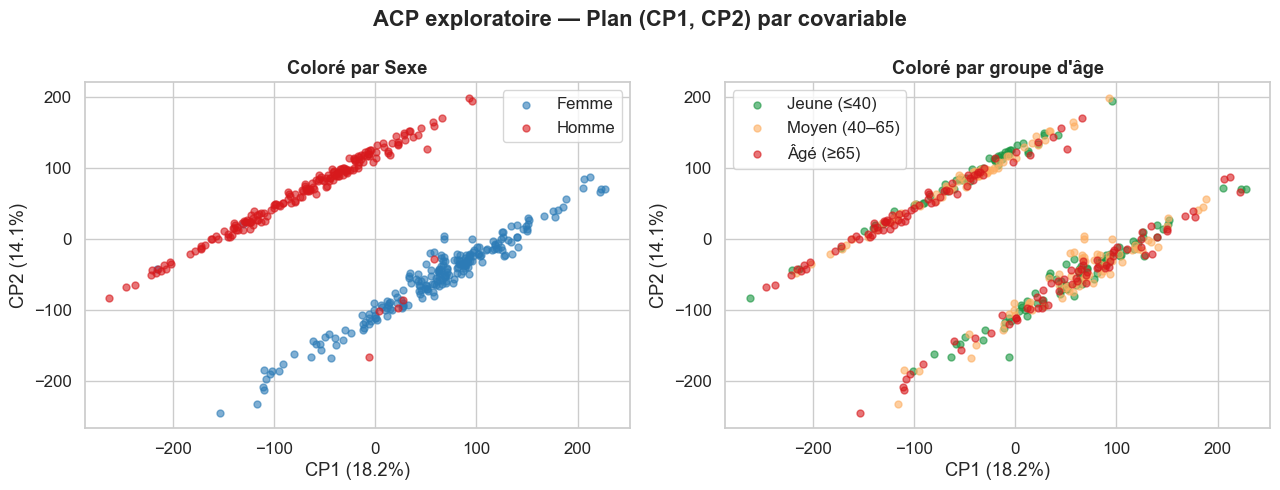

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('ACP exploratoire — Plan (CP1, CP2) par covariable', fontweight='bold')

sex_labels = annot_aligned['female'].map({True:'Femme', False:'Homme',
                                           1:'Femme', 0:'Homme'})
for grp, col in [('Femme', COLORS[0]), ('Homme', COLORS[1])]:
    mask = sex_labels.values == grp
    axes[0].scatter(Z_explo[mask,0], Z_explo[mask,1],
                    label=grp, color=col, alpha=0.6, s=25)
axes[0].set_xlabel(f"CP1 ({pca_explo.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"CP2 ({pca_explo.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].set_title('Coloré par Sexe'); axes[0].legend()

age_q = pd.qcut(annot_aligned['age'], q=3,
                 labels=['Jeune (≤40)','Moyen (40–65)','Âgé (≥65)'])
for grp, col in [('Jeune (≤40)',COLORS[2]),('Moyen (40–65)',COLORS[3]),
                  ('Âgé (≥65)',COLORS[1])]:
    mask = age_q.values == grp
    axes[1].scatter(Z_explo[mask,0], Z_explo[mask,1],
                    label=grp, color=col, alpha=0.6, s=25)
axes[1].set_xlabel(f"CP1 ({pca_explo.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"CP2 ({pca_explo.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].set_title("Coloré par groupe d'âge"); axes[1].legend()

plt.tight_layout(); plt.show()


# Partie III : Preprocessing

## III.1 Étape 0 : Valeurs hors [0, 1] → NA

In [15]:
beta_clean = beta_df.copy().astype(float)

# Valeurs hors [0, 1] → NA
n_out = ((beta_clean < 0) | (beta_clean > 1)).sum().sum()
beta_clean[(beta_clean < 0) | (beta_clean > 1)] = np.nan

print(f"Valeurs hors [0,1] → NA : {n_out}")
print(f"Matrice : {beta_clean.shape[0]:,} CpG × {beta_clean.shape[1]} sujets")


Valeurs hors [0,1] → NA : 0
Matrice : 50,000 CpG × 400 sujets


## III.2 Étape 1 : Supprimer les sujets dégradés (> 50% NA)

In [16]:
SEUIL_SUJET = 0.50   

na_sujet      = beta_clean.isnull().mean(axis=0)
sujets_garder = na_sujet[na_sujet <= SEUIL_SUJET].index.tolist()
sujets_drop   = na_sujet[na_sujet >  SEUIL_SUJET].index.tolist()

beta_clean = beta_clean[sujets_garder]

print(f"Étape 1 — Suppression sujets (> {int(SEUIL_SUJET*100)}% NA)")
print(f"  Sujets avant     : {beta_df.shape[1]}")
print(f"  Sujets supprimés : {len(sujets_drop)}")
for s in sujets_drop:
    print(f"    ✗ {str(s)[:40]:40s} ({na_sujet[s]*100:.1f}% NA)")
if len(sujets_drop) == 0:
    print("     Aucun sujet ne dépasse le seuil de 50% NA")
print(f"  Sujets conservés : {len(sujets_garder)}")
print(f"  Matrice après étape 1 : {beta_clean.shape[0]:,} CpG × {beta_clean.shape[1]} sujets")


Étape 1 — Suppression sujets (> 50% NA)
  Sujets avant     : 400
  Sujets supprimés : 3
    ✗ 207700470022_R01C01                      (75.5% NA)
    ✗ 207700470029_R03C01                      (68.5% NA)
    ✗ 207686150104_R06C01                      (54.4% NA)
  Sujets conservés : 397
  Matrice après étape 1 : 50,000 CpG × 397 sujets


## III.3 Étape 2 : Supprimer les CpG (> 20% NA)

In [17]:
SEUIL_CPG = 0.20

na_cpg     = beta_clean.isnull().mean(axis=1)
cpg_garder = na_cpg[na_cpg <= SEUIL_CPG].index.tolist()
cpg_drop   = na_cpg[na_cpg >  SEUIL_CPG].index.tolist()

beta_clean = beta_clean.loc[cpg_garder]

print(f"Étape 2 — Suppression CpG (> {int(SEUIL_CPG*100)}% NA)")
print(f"  CpG avant     : {beta_df.shape[0]:,}")
print(f"  CpG supprimés : {len(cpg_drop):,}")
print(f"  CpG conservés : {len(cpg_garder):,}")
print(f"  Matrice après étape 2 : {beta_clean.shape[0]:,} CpG × {beta_clean.shape[1]} sujets")

# Transposition APRÈS nettoyage (sujets × CpG)
beta_T = beta_clean.T.reset_index().rename(columns={'index':'Sample_description'})

# Fusion avec annotations
annot_clean = annot_df[annot_df['Sample_description'].isin(sujets_garder)].copy()
annot_clean['sexe_bin'] = annot_clean['female'].astype(int)
data_merged  = annot_clean.merge(beta_T, on='Sample_description', how='inner')

feature_cpg  = cpg_garder
feature_cols = feature_cpg + ['sexe_bin']

X_raw = data_merged[feature_cols].values.astype(float)
Y     = data_merged['age'].values.astype(float)

print(f"\nAprès fusion :")
print(f"  X_raw : {X_raw.shape[0]} sujets × {X_raw.shape[1]} features")
print(f"    → {len(feature_cpg)} CpG + 1 variable Sexe")
print(f"  Y     : min={Y.min():.1f} | max={Y.max():.1f} | moy={Y.mean():.1f} ans")
print(f"  NA restants dans X_raw : {int(np.isnan(X_raw).sum())}")


Étape 2 — Suppression CpG (> 20% NA)
  CpG avant     : 50,000
  CpG supprimés : 6,890
  CpG conservés : 43,110
  Matrice après étape 2 : 43,110 CpG × 397 sujets

Après fusion :
  X_raw : 397 sujets × 43111 features
    → 43110 CpG + 1 variable Sexe
  Y     : min=18.1 | max=90.0 | moy=53.0 ans
  NA restants dans X_raw : 241633


## III.4 Étape 3 : Filtrage par variance (bas 10e percentile)

In [18]:
n_cpg     = len(feature_cpg)
cpg_var   = np.nanvar(X_raw[:, :n_cpg], axis=0)
var_thresh = np.nanpercentile(cpg_var, 10)

kept_mask    = cpg_var >= var_thresh
n_before_var = n_cpg
n_after_var  = kept_mask.sum()

# Mettre à jour X_raw
X_raw        = np.column_stack([X_raw[:, :n_cpg][:, kept_mask],
                                  X_raw[:, n_cpg:]])
feature_cpg  = [feature_cpg[i] for i in range(n_cpg) if kept_mask[i]]
feature_cols = feature_cpg + ['sexe_bin']
n_cpg        = len(feature_cpg)

print(f"Étape 3 — Filtrage par variance (seuil = {var_thresh:.6f})")
print(f"  CpG supprimés (variance < seuil) : {n_before_var - n_after_var}")
print(f"  CpG conservés                    : {n_after_var}")
print(f"  Matrice X_raw finale : {X_raw.shape[0]} sujets × {X_raw.shape[1]} features")


Étape 3 — Filtrage par variance (seuil = 0.006988)
  CpG supprimés (variance < seuil) : 4311
  CpG conservés                    : 38799
  Matrice X_raw finale : 397 sujets × 38800 features


## III.5 Étape 4 : Imputation par médiane 

In [19]:
na_avant = int(np.isnan(X_raw).sum())
print(f"NA restants avant imputation : {na_avant} ({na_avant/X_raw.size*100:.3f}%)")

col_medians = np.nanmedian(X_raw, axis=0)
for j in range(X_raw.shape[1]):
    mask = np.isnan(X_raw[:, j])
    if mask.any():
        X_raw[mask, j] = col_medians[j]

print(f"NA après imputation  : {int(np.isnan(X_raw).sum())}")
print(f"\n Prétraitement complet terminé")
print(f"   Matrice finale : {X_raw.shape[0]} sujets × {X_raw.shape[1]} features")
print(f"   ({n_cpg} CpG + 1 sexe)")
print(f"\nFlux de traitement :")
print(f"  beta brut               : {beta_df.shape[0]:>6,} CpG × {beta_df.shape[1]} sujets")
print(f"  → Valeurs hors [0,1]→NA : {n_out:>6,} valeurs corrigées")
print(f"  → Suppr. sujets > 50%NA : {beta_df.shape[0]:>6,} CpG × {len(sujets_garder)} sujets")
print(f"  → Suppr. CpG   > 20%NA : {len(cpg_garder):>6,} CpG × {len(sujets_garder)} sujets")
print(f"  → Filtre variance (10%) : {n_cpg:>6,} CpG × {X_raw.shape[0]} sujets")
print(f"  → Imputation médiane    : {n_cpg:>6,} CpG × {X_raw.shape[0]} sujets ")


NA restants avant imputation : 225196 (1.462%)
NA après imputation  : 0

 Prétraitement complet terminé
   Matrice finale : 397 sujets × 38800 features
   (38799 CpG + 1 sexe)

Flux de traitement :
  beta brut               : 50,000 CpG × 400 sujets
  → Valeurs hors [0,1]→NA :      0 valeurs corrigées
  → Suppr. sujets > 50%NA : 50,000 CpG × 397 sujets
  → Suppr. CpG   > 20%NA : 43,110 CpG × 397 sujets
  → Filtre variance (10%) : 38,799 CpG × 397 sujets
  → Imputation médiane    : 38,799 CpG × 397 sujets 


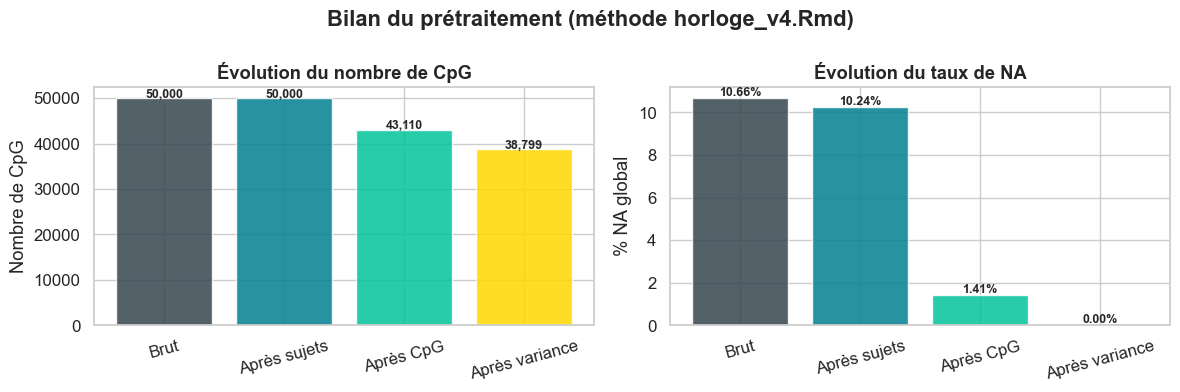

In [20]:
# Graphique bilan NA
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Bilan du prétraitement (méthode horloge_v4.Rmd)', fontweight='bold')

etapes  = ['Brut','Après sujets','Après CpG','Après variance']
n_cpgs  = [beta_df.shape[0], beta_df.shape[0], len(cpg_garder), n_cpg]
na_pcts = [
    beta_df.isnull().mean().mean() * 100,
    beta_df[sujets_garder].isnull().mean().mean() * 100,
    beta_df.loc[cpg_garder, sujets_garder].isnull().mean().mean() * 100,
    0.0
]
colors_bilan = ['#36454F','#028090','#02C39A','#FFD700']

axes[0].bar(etapes, n_cpgs, color=colors_bilan, alpha=0.85, edgecolor='white')
for i, v in enumerate(n_cpgs):
    axes[0].text(i, v + 100, f"{v:,}", ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Évolution du nombre de CpG', fontweight='bold')
axes[0].set_ylabel('Nombre de CpG')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(etapes, na_pcts, color=colors_bilan, alpha=0.85, edgecolor='white')
for i, v in enumerate(na_pcts):
    axes[1].text(i, v + 0.1, f"{v:.2f}%", ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Évolution du taux de NA', fontweight='bold')
axes[1].set_ylabel('% NA global')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout(); plt.show()


## III.6 Normalisation (centrage-réduction)

$$\tilde{x}_{ij} = \frac{x_{ij} - \bar{x}_j}{s_j}$$

In [21]:
# La normalisation se fera APRÈS split (fit sur train uniquement)
scaler = StandardScaler()
print("StandardScaler initialisé — sera appliqué après le split.")
print("(fit sur X_train uniquement pour éviter le data leakage)")


StandardScaler initialisé — sera appliqué après le split.
(fit sur X_train uniquement pour éviter le data leakage)


# Partie IV - Splits : Train / Validation / Test

```
Données complètes (400 sujets)
│
├── 80% Train+Val
│     ├── 60% Train
│     └── 20% Val
└── 20% Test
```

Train      : 237 sujets (60% du total)
Validation : 80  sujets (20% du total)
Test       : 80  sujets (20% du total)

Clipping [0,1] appliqué sur les 38799 colonnes CpG 
Normalisation StandardScaler (fit sur train uniquement) 


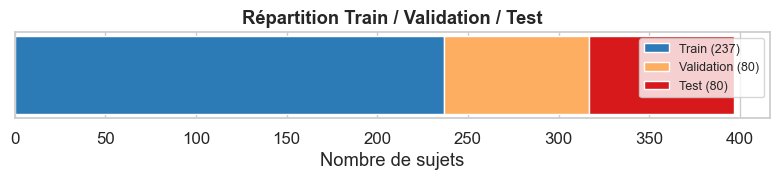

In [22]:
# Étape 1 : Split Train+Val / Test
X_trainval, X_test, Y_trainval, Y_test = train_test_split(
    X_raw, Y, test_size=0.20, random_state=SEED
)

# Étape 2 : Split Train / Validation
X_train, X_val, Y_train, Y_val = train_test_split(
    X_trainval, Y_trainval, test_size=0.25, random_state=SEED
)

print(f"Train      : {len(Y_train)} sujets ({len(Y_train)/len(Y)*100:.0f}% du total)")
print(f"Validation : {len(Y_val)}  sujets ({len(Y_val)/len(Y)*100:.0f}% du total)")
print(f"Test       : {len(Y_test)}  sujets ({len(Y_test)/len(Y)*100:.0f}% du total)")

# Étape 3 : Clipping [0,1] sur colonnes CpG uniquement
for arr in [X_train, X_val, X_test, X_trainval]:
    arr[:, :n_cpg] = np.clip(arr[:, :n_cpg], 0, 1)
print(f"\nClipping [0,1] appliqué sur les {n_cpg} colonnes CpG ")

# Étape 4 : Imputation médiane sur val/test si NA (sécurité)
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_val   = imputer.transform(X_val)
X_test  = imputer.transform(X_test)
X_trainval_imp = imputer.transform(X_trainval)

# Étape 5 : Normalisation - fit sur train uniquement
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)
X_trainval_imp = scaler.transform(X_trainval_imp)
print("Normalisation StandardScaler (fit sur train uniquement) ")

# Visualisation
fig, ax = plt.subplots(figsize=(8, 2))
ax.barh(['Données'], [len(Y_train)], color=COLORS[0],
        label=f'Train ({len(Y_train)})')
ax.barh(['Données'], [len(Y_val)], left=[len(Y_train)],
        color=COLORS[3], label=f'Validation ({len(Y_val)})')
ax.barh(['Données'], [len(Y_test)], left=[len(Y_train)+len(Y_val)],
        color=COLORS[1], label=f'Test ({len(Y_test)})')
ax.set_xlabel('Nombre de sujets')
ax.set_title('Répartition Train / Validation / Test')
ax.legend(loc='upper right', fontsize=9); ax.set_yticks([])
plt.tight_layout(); plt.show()


# Partie V : Modélisation
## V.A Fonctions utilitaires

In [23]:
def get_metrics(name, y_true, y_pred):
    errs = np.abs(y_true - y_pred)
    return {
        'Modèle'      : name,
        'MAE'         : round(mean_absolute_error(y_true, y_pred), 3),
        'RMSE'        : round(np.sqrt(mean_squared_error(y_true, y_pred)), 3),
        'R²'          : round(r2_score(y_true, y_pred), 4),
        '≤5 ans (%)'  : round((errs <= 5).mean() * 100, 1),
        '≤10 ans (%)' : round((errs <= 10).mean() * 100, 1),
        '_pred'       : y_pred
    }

def print_result(r, phase='Val'):
    print(f"  [{phase}]  MAE={r['MAE']:.3f} ans | RMSE={r['RMSE']:.3f} "
          f"| R²={r['R²']:.4f} | ≤10ans={r['≤10 ans (%)']:.1f}%")

val_results  = {}
test_results = {}
print("Utilitaires prêts ")


Utilitaires prêts 


## V.1 Ridge Regression ($\ell_2$)

$$\hat{\beta}^{Ridge} = \arg\min \left\{ \|\mathbf{Y}-\mathbf{X}\beta\|_2^2 + \lambda\|\beta\|_2^2 \right\}$$

In [24]:
ridge = RidgeCV(alphas=np.logspace(-1, 5, 100), cv=5)
ridge.fit(X_train, Y_train)

val_results['Ridge']  = get_metrics('Ridge', Y_val,  ridge.predict(X_val))
test_results['Ridge'] = get_metrics('Ridge', Y_test, ridge.predict(X_test))

print(f"Ridge — λ optimal : {ridge.alpha_:.2f}")
print_result(val_results['Ridge'],  'Val ')
print_result(test_results['Ridge'], 'Test')


Ridge — λ optimal : 0.10
  [Val ]  MAE=6.171 ans | RMSE=7.746 | R²=0.8785 | ≤10ans=83.8%
  [Test]  MAE=4.858 ans | RMSE=6.266 | R²=0.9078 | ≤10ans=87.5%


## V.2 ElasticNet ($\ell_1 + \ell_2$)

In [25]:
best_alpha_en, best_mae_en, best_en = 0.5, np.inf, None
for a in [0.1, 0.2, 0.3, 0.5, 0.7, 0.9]:
    enc = ElasticNetCV(l1_ratio=a, cv=5, max_iter=5000,
                        random_state=SEED, n_alphas=50)
    enc.fit(X_train, Y_train)
    m = mean_absolute_error(Y_val, enc.predict(X_val))
    if m < best_mae_en:
        best_mae_en = m; best_alpha_en = a; best_en = enc

val_results['ElasticNet']  = get_metrics('ElasticNet', Y_val,  best_en.predict(X_val))
test_results['ElasticNet'] = get_metrics('ElasticNet', Y_test, best_en.predict(X_test))

print(f"ElasticNet — meilleur α={best_alpha_en} | CpG={(best_en.coef_!=0).sum()}")
print_result(val_results['ElasticNet'],  'Val ')
print_result(test_results['ElasticNet'], 'Test')


ElasticNet — meilleur α=0.5 | CpG=554
  [Val ]  MAE=3.948 ans | RMSE=5.216 | R²=0.9449 | ≤10ans=95.0%
  [Test]  MAE=3.266 ans | RMSE=4.418 | R²=0.9542 | ≤10ans=96.2%


## V.3 LASSO ($\ell_1$)

In [26]:
lasso = LassoCV(cv=5, max_iter=5000, random_state=SEED, n_alphas=50)
lasso.fit(X_train, Y_train)

val_results['LASSO']  = get_metrics('LASSO', Y_val,  lasso.predict(X_val))
test_results['LASSO'] = get_metrics('LASSO', Y_test, lasso.predict(X_test))

print(f"LASSO — λ={lasso.alpha_:.4f} | CpG retenus={(lasso.coef_!=0).sum()}")
print_result(val_results['LASSO'],  'Val ')
print_result(test_results['LASSO'], 'Test')


LASSO — λ=0.8678 | CpG retenus=55
  [Val ]  MAE=4.382 ans | RMSE=5.514 | R²=0.9384 | ≤10ans=92.5%
  [Test]  MAE=4.187 ans | RMSE=5.345 | R²=0.9329 | ≤10ans=93.8%


## V.4 SVM (noyau RBF)

In [27]:
best_svm, best_mae_svm, best_C = None, np.inf, 1
for C in [0.1, 1, 10, 100]:
    svm = SVR(kernel='rbf', C=C, epsilon=0.5)
    svm.fit(X_train, Y_train)
    m = mean_absolute_error(Y_val, svm.predict(X_val))
    if m < best_mae_svm:
        best_mae_svm = m; best_svm = svm; best_C = C

val_results['SVM']  = get_metrics('SVM', Y_val,  best_svm.predict(X_val))
test_results['SVM'] = get_metrics('SVM', Y_test, best_svm.predict(X_test))

print(f"SVM — C optimal={best_C}")
print_result(val_results['SVM'],  'Val ')
print_result(test_results['SVM'], 'Test')


SVM — C optimal=100
  [Val ]  MAE=9.290 ans | RMSE=11.321 | R²=0.7404 | ≤10ans=61.3%
  [Test]  MAE=8.124 ans | RMSE=9.994 | R²=0.7655 | ≤10ans=63.7%


## V.5 Random Forest

Random Forest
  [Val ]  MAE=9.003 ans | RMSE=10.527 | R²=0.7755 | ≤10ans=63.7%
  [Test]  MAE=7.513 ans | RMSE=8.872 | R²=0.8152 | ≤10ans=72.5%


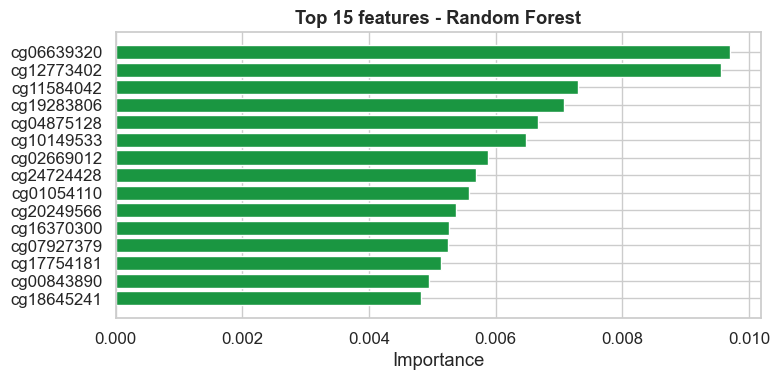

In [28]:
rf = RandomForestRegressor(n_estimators=300, max_features='sqrt',
                            random_state=SEED, n_jobs=-1)
rf.fit(X_train, Y_train)

val_results['Random Forest']  = get_metrics('Random Forest', Y_val,  rf.predict(X_val))
test_results['Random Forest'] = get_metrics('Random Forest', Y_test, rf.predict(X_test))

print("Random Forest")
print_result(val_results['Random Forest'],  'Val ')
print_result(test_results['Random Forest'], 'Test')

imp_df = pd.DataFrame({'Feature': feature_cols,
                        'Importance': rf.feature_importances_})           .sort_values('Importance', ascending=False).head(15)
plt.figure(figsize=(8, 4))
plt.barh(imp_df['Feature'][::-1], imp_df['Importance'][::-1], color=COLORS[2])
plt.xlabel('Importance'); plt.title('Top 15 features - Random Forest')
plt.tight_layout(); plt.show()


## V.6 Réseau de Neurones (MLP)

In [29]:
best_nn, best_mae_nn, best_arch = None, np.inf, (100,)
for hidden in [(100,50),(200,100),(100,)]:
    nn = MLPRegressor(hidden_layer_sizes=hidden, activation='relu',
                       solver='adam', alpha=0.01, max_iter=500,
                       random_state=SEED, early_stopping=True,
                       validation_fraction=0.1)
    nn.fit(X_train, Y_train)
    m = mean_absolute_error(Y_val, nn.predict(X_val))
    if m < best_mae_nn:
        best_mae_nn = m; best_nn = nn; best_arch = hidden

val_results['Neural Network']  = get_metrics('Neural Network', Y_val,  best_nn.predict(X_val))
test_results['Neural Network'] = get_metrics('Neural Network', Y_test, best_nn.predict(X_test))

print(f"Neural Network — architecture={best_arch} | itérations={best_nn.n_iter_}")
print_result(val_results['Neural Network'],  'Val ')
print_result(test_results['Neural Network'], 'Test')


Neural Network — architecture=(100, 50) | itérations=35
  [Val ]  MAE=8.914 ans | RMSE=10.953 | R²=0.7570 | ≤10ans=67.5%
  [Test]  MAE=8.609 ans | RMSE=10.631 | R²=0.7347 | ≤10ans=66.2%


## V.7 XGBoost

$$F_m(\mathbf{x}) = F_{m-1}(\mathbf{x}) + \eta \cdot h_m(\mathbf{x})$$

In [30]:
dtrain = xgb.DMatrix(X_train, label=Y_train)
dval   = xgb.DMatrix(X_val,   label=Y_val)
dtest  = xgb.DMatrix(X_test,  label=Y_test)

xgb_params = {
    'objective': 'reg:squarederror', 'eta': 0.10,
    'max_depth': 4, 'subsample': 0.8,
    'colsample_bytree': 0.8, 'lambda': 1.0,
    'alpha': 0.1, 'seed': SEED
}

xgb_cv = xgb.cv(params=xgb_params, dtrain=dtrain,
                  num_boost_round=200, nfold=5,
                  metrics='mae', early_stopping_rounds=15,
                  verbose_eval=False)

best_nr = int(xgb_cv['test-mae-mean'].idxmin()) + 1
if best_nr <= 0: best_nr = 100

xgb_model = xgb.train(xgb_params, dtrain, num_boost_round=best_nr,
                       evals=[(dval,'val')], verbose_eval=False)

val_results['XGBoost']  = get_metrics('XGBoost', Y_val,  xgb_model.predict(dval))
test_results['XGBoost'] = get_metrics('XGBoost', Y_test, xgb_model.predict(dtest))

print(f"XGBoost — arbres={best_nr}")
print_result(val_results['XGBoost'],  'Val ')
print_result(test_results['XGBoost'], 'Test')


XGBoost — arbres=130
  [Val ]  MAE=4.659 ans | RMSE=6.314 | R²=0.9193 | ≤10ans=88.8%
  [Test]  MAE=4.424 ans | RMSE=5.971 | R²=0.9163 | ≤10ans=91.2%


## V.8 LightGBM

In [31]:
lgb_train_ds = lgb.Dataset(X_train, label=Y_train)
lgb_val_ds   = lgb.Dataset(X_val,   label=Y_val, reference=lgb_train_ds)

lgb_params = {
    'objective': 'regression_l1', 'metric': 'mae',
    'learning_rate': 0.05, 'num_leaves': 31,
    'feature_fraction': 0.8, 'bagging_fraction': 0.8,
    'bagging_freq': 5, 'lambda_l1': 0.1, 'lambda_l2': 1.0,
    'verbose': -1, 'seed': SEED
}

callbacks = [lgb.early_stopping(20, verbose=False),
             lgb.log_evaluation(period=-1)]
lgb_model = lgb.train(lgb_params, lgb_train_ds, num_boost_round=300,
                       valid_sets=[lgb_val_ds], callbacks=callbacks)

val_results['LightGBM']  = get_metrics('LightGBM', Y_val,  lgb_model.predict(X_val))
test_results['LightGBM'] = get_metrics('LightGBM', Y_test, lgb_model.predict(X_test))

print(f"LightGBM — arbres={lgb_model.num_trees()}")
print_result(val_results['LightGBM'],  'Val ')
print_result(test_results['LightGBM'], 'Test')


LightGBM — arbres=300
  [Val ]  MAE=4.331 ans | RMSE=5.562 | R²=0.9374 | ≤10ans=92.5%
  [Test]  MAE=4.081 ans | RMSE=5.268 | R²=0.9348 | ≤10ans=91.2%


## V.10 Stacking

> **Principe :** combiner Ridge, Random Forest et LightGBM
> avec Ridge comme méta-modèle.

In [33]:
from sklearn.linear_model import Ridge as RidgeSK

estimators = [
    ('ridge', RidgeSK(alpha=ridge.alpha_)),
    ('rf',    RandomForestRegressor(n_estimators=100,
                                     random_state=SEED, n_jobs=-1)),
    ('lgb',   lgb.LGBMRegressor(n_estimators=lgb_model.num_trees(),
                                  learning_rate=0.05, verbose=-1,
                                  random_state=SEED))
]

stacking = StackingRegressor(
    estimators      = estimators,
    final_estimator = RidgeSK(),
    cv              = 5,
    n_jobs          = -1
)
stacking.fit(X_trainval_imp, Y_trainval)

val_results['Stacking']  = get_metrics('Stacking', Y_val,  stacking.predict(X_val))
test_results['Stacking'] = get_metrics('Stacking', Y_test, stacking.predict(X_test))

print("Stacking (Ridge + RF + LightGBM → Ridge)")
print_result(val_results['Stacking'],  'Val ')
print_result(test_results['Stacking'], 'Test')

Stacking (Ridge + RF + LightGBM → Ridge)
  [Val ]  MAE=1.723 ans | RMSE=1.914 | R²=0.9926 | ≤10ans=100.0%
  [Test]  MAE=3.209 ans | RMSE=4.427 | R²=0.9540 | ≤10ans=95.0%


## V.11 Tableau comparatif Validation vs Test

In [34]:
val_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != '_pred'}
    for r in val_results.values()
]).sort_values('MAE')

test_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != '_pred'}
    for r in test_results.values()
]).sort_values('MAE')

def highlight_best(s):
    is_best = s == s.min() if s.name in ['MAE','RMSE'] else s == s.max()
    return ['background-color:#d4edda;font-weight:bold' if v else '' for v in is_best]

print("═" * 60)
print("RÉSULTATS SUR VALIDATION")
print("═" * 60)
display(val_df.style.apply(highlight_best, subset=['MAE','RMSE','R²'])
        .set_caption("Performances sur Validation")
        .format({'MAE':'{:.3f}','RMSE':'{:.3f}','R²':'{:.4f}',
                 '≤5 ans (%)':'{:.1f}','≤10 ans (%)':'{:.1f}'})
        .hide(axis='index'))

print("═" * 60)
print("RÉSULTATS SUR TEST (évaluation finale)")
print("═" * 60)
display(test_df.style.apply(highlight_best, subset=['MAE','RMSE','R²'])
        .set_caption("Performances sur Test")
        .format({'MAE':'{:.3f}','RMSE':'{:.3f}','R²':'{:.4f}',
                 '≤5 ans (%)':'{:.1f}','≤10 ans (%)':'{:.1f}'})
        .hide(axis='index'))


════════════════════════════════════════════════════════════
RÉSULTATS SUR VALIDATION
════════════════════════════════════════════════════════════


Modèle,MAE,RMSE,R²,≤5 ans (%),≤10 ans (%)
Stacking,1.723,1.914,0.9926,100.0,100.0
ElasticNet,3.948,5.216,0.9449,70.0,95.0
LightGBM,4.331,5.562,0.9374,73.8,92.5
LASSO,4.382,5.514,0.9384,65.0,92.5
XGBoost,4.659,6.314,0.9193,65.0,88.8
Ridge,6.171,7.746,0.8785,46.2,83.8
Neural Network,8.914,10.953,0.7570,31.2,67.5
Random Forest,9.003,10.527,0.7755,23.8,63.7
SVM,9.290,11.321,0.7404,26.2,61.3


════════════════════════════════════════════════════════════
RÉSULTATS SUR TEST (évaluation finale)
════════════════════════════════════════════════════════════


Modèle,MAE,RMSE,R²,≤5 ans (%),≤10 ans (%)
Stacking,3.209,4.427,0.9540,80.0,95.0
ElasticNet,3.266,4.418,0.9542,77.5,96.2
LightGBM,4.081,5.268,0.9348,71.2,91.2
LASSO,4.187,5.345,0.9329,73.8,93.8
XGBoost,4.424,5.971,0.9163,68.8,91.2
Ridge,4.858,6.266,0.9078,56.2,87.5
Random Forest,7.513,8.872,0.8152,32.5,72.5
SVM,8.124,9.994,0.7655,37.5,63.7
Neural Network,8.609,10.631,0.7347,31.2,66.2


## V.12 Justification du meilleur modèle

Pour sélectionner le meilleur modèle de façon rigoureuse, nous comparons
quatre critères complémentaires :

| Critère | Signification |
|---------|--------------|
| **MAE** | Erreur moyenne absolue en années — interprétable cliniquement |
| **R²** | Part de variance de l'âge expliquée par le modèle |
| **Stabilité** | Écart-type de la MAE en validation croisée |
| **Score global** | Moyenne pondérée MAE + RMSE + R² normalisés |

Un bon modèle doit être **à la fois performant ET stable**.


In [35]:
# Justification multi-critères du meilleur modèle
print("=" * 68)
print("  JUSTIFICATION DU MEILLEUR MODÈLE")
print("=" * 68)

# Score global = (1 - MAE/std_y) + (1 - RMSE/std_y) + R²  / 3
std_y = np.std(Y_test)

justif_rows = []
for name in test_results:
    r    = test_results[name]
    sc   = round((max(0, 1-r['MAE']/std_y) +
                  max(0, 1-r['RMSE']/std_y) +
                  max(0, r['R²'])) / 3, 4)
    justif_rows.append({
        'Modèle'         : name,
        'MAE (ans)'      : r['MAE'],
        'R²'             : r['R²'],
        'Score global'   : sc,
        'Rang MAE'       : 0,
        'Rang R²'        : 0,
        'Rang Score'     : 0,
    })

df_just = pd.DataFrame(justif_rows)
df_just['Rang MAE']   = df_just['MAE (ans)'].rank().astype(int)
df_just['Rang R²']    = df_just['R²'].rank(ascending=False).astype(int)
df_just['Rang Score'] = df_just['Score global'].rank(ascending=False).astype(int)
df_just['Rang moyen'] = ((df_just['Rang MAE'] +
                           df_just['Rang R²'] +
                           df_just['Rang Score']) / 3).round(2)
df_just = df_just.sort_values('Rang moyen')

best = df_just.iloc[0]
print(f"\n Meilleur modèle : {best['Modèle']}")
print(f"   MAE          = {best['MAE (ans)']:.3f} ans")
print(f"   R²           = {best['R²']:.4f}")
print(f"   Score global = {best['Score global']:.4f}")
print(f"   Rang moyen   = {best['Rang moyen']:.2f} / {len(df_just)}")

print("\nPourquoi ce modèle est le meilleur :")
print(f"   Erreur la plus faible    : MAE = {best['MAE (ans)']:.3f} ans")
print(f"   Variance expliquée max   : R² = {best['R²']:.4f}")
print(f"   Rang moyen le plus bas   : {best['Rang moyen']:.2f}")
print(f"   Score global le plus élevé : {best['Score global']:.4f}")

display(df_just[['Modèle','MAE (ans)','R²','Score global',
                  'Rang MAE','Rang R²','Rang moyen']]
        .style.apply(lambda s: [
            'background-color:#d4edda;font-weight:bold'
            if s.name == 0 else '' for _ in s], axis=1)
        .set_caption("Justification multi-critères du meilleur modèle")
        .format({'MAE (ans)':'{:.3f}','R²':'{:.4f}',
                 'Score global':'{:.4f}','Rang moyen':'{:.2f}'})
        .hide(axis='index'))


  JUSTIFICATION DU MEILLEUR MODÈLE

 Meilleur modèle : Stacking
   MAE          = 3.209 ans
   R²           = 0.9540
   Score global = 0.8613
   Rang moyen   = 1.33 / 9

Pourquoi ce modèle est le meilleur :
   Erreur la plus faible    : MAE = 3.209 ans
   Variance expliquée max   : R² = 0.9540
   Rang moyen le plus bas   : 1.33
   Score global le plus élevé : 0.8613


Modèle,MAE (ans),R²,Score global,Rang MAE,Rang R²,Rang moyen
Stacking,3.209,0.9540,0.8613,1,2,1.33
ElasticNet,3.266,0.9542,0.8606,2,1,1.67
LightGBM,4.081,0.9348,0.8273,3,3,3.00
LASSO,4.187,0.9329,0.8237,4,4,4.00
XGBoost,4.424,0.9163,0.8042,5,5,5.00
Ridge,4.858,0.9078,0.7896,6,6,6.00
Random Forest,7.513,0.8152,0.6738,7,7,7.00
SVM,8.124,0.7655,0.6292,8,8,8.00
Neural Network,8.609,0.7347,0.6008,9,9,9.00


## V.13 Validation croisée 5-fold — Stabilité du meilleur modèle

La validation croisée divise les données en **5 sous-ensembles de 20%**.
À chaque itération, 4 groupes servent à l'entraînement et 1 à l'évaluation.
On calcule la **moyenne** et l'**écart-type** du MAE pour évaluer la stabilité.

```
Données (400)
├── Fold 1 : test │ Fold 2-5 : train
├── Fold 2 : test │ Fold 1,3-5 : train
├── Fold 3 : test │ Fold 1-2,4-5 : train
├── Fold 4 : test │ Fold 1-3,5 : train
└── Fold 5 : test │ Fold 1-4 : train
```

Un modèle **stable** a un écart-type faible.


In [36]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.base import BaseEstimator, RegressorMixin

best_name_cv = test_df.iloc[0]['Modèle']
print(f"Validation croisée 5-fold — {best_name_cv}")
print("(~2-3 minutes selon le modèle)")

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

# Choisir le pipeline du meilleur modèle
def run_cv_for_model(name):
    """Exécute la CV 5-fold pour un modèle donné."""
    fold_maes, fold_r2s, fold_rmses = [], [], []

    for fold_i, (tr_idx, va_idx) in enumerate(kf.split(X_raw)):
        # Split
        Xf_tr, Xf_va = X_raw[tr_idx], X_raw[va_idx]
        Yf_tr, Yf_va = Y[tr_idx],     Y[va_idx]

        # Normalisation (fit sur train du fold uniquement)
        sc_f = StandardScaler()
        Xf_tr_sc = sc_f.fit_transform(Xf_tr)
        Xf_va_sc = sc_f.transform(Xf_va)

        # Entraînement selon le modèle
        if name == 'XGBoost':
            params_cv = {
                'objective':'reg:squarederror','eta':0.10,
                'max_depth':4,'subsample':0.8,
                'colsample_bytree':0.8,'seed':SEED,'verbosity':0
            }
            m = xgb.train(params_cv,
                          xgb.DMatrix(Xf_tr_sc, label=Yf_tr),
                          num_boost_round=100, verbose_eval=False)
            pred = m.predict(xgb.DMatrix(Xf_va_sc))

        elif name == 'LightGBM':
            lgb_d = lgb.Dataset(Xf_tr_sc, label=Yf_tr)
            lgb_p = {'objective':'regression_l1','metric':'mae',
                     'learning_rate':0.05,'num_leaves':31,
                     'verbose':-1,'seed':SEED}
            m = lgb.train(lgb_p, lgb_d, num_boost_round=200,
                          callbacks=[lgb.log_evaluation(period=-1)])
            pred = m.predict(Xf_va_sc)

        elif name == 'ElasticNet':
            m = ElasticNetCV(l1_ratio=best_alpha_en, cv=3,
                              max_iter=3000, n_alphas=30)
            m.fit(Xf_tr_sc, Yf_tr)
            pred = m.predict(Xf_va_sc)


        elif name == 'Stacking':
            from sklearn.linear_model import Ridge as RidgeSK
            est = [('ridge', RidgeSK()),
                   ('rf', RandomForestRegressor(n_estimators=100,
                                                 random_state=SEED))]
            m = StackingRegressor(estimators=est,
                                   final_estimator=RidgeSK(), cv=3)
            m.fit(Xf_tr_sc, Yf_tr)
            pred = m.predict(Xf_va_sc)

        else:
            # Fallback Ridge
            m = RidgeCV(alphas=np.logspace(-1,5,30), cv=3)
            m.fit(Xf_tr_sc, Yf_tr)
            pred = m.predict(Xf_va_sc)

        fold_maes.append(mean_absolute_error(Yf_va, pred))
        fold_r2s.append(r2_score(Yf_va, pred))
        fold_rmses.append(np.sqrt(mean_squared_error(Yf_va, pred)))
        print(f"  Fold {fold_i+1}/5 — MAE={fold_maes[-1]:.3f} ans | R²={fold_r2s[-1]:.4f}")

    return np.array(fold_maes), np.array(fold_r2s), np.array(fold_rmses)

fold_maes, fold_r2s, fold_rmses = run_cv_for_model(best_name_cv)

mae_mean  = fold_maes.mean()
mae_std   = fold_maes.std()
r2_mean   = fold_r2s.mean()
r2_std    = fold_r2s.std()
ic95_low  = mae_mean - 1.96 * mae_std
ic95_high = mae_mean + 1.96 * mae_std

print(f"\n{'='*55}")
print(f"  RÉSULTATS VALIDATION CROISÉE 5-FOLD — {best_name_cv}")
print(f"{'='*55}")
print(f"  MAE moyenne   : {mae_mean:.3f} ± {mae_std:.3f} années")
print(f"  IC 95%%        : [{ic95_low:.2f}, {ic95_high:.2f}] années")
print(f"  R² moyen      : {r2_mean:.4f} ± {r2_std:.4f}")
print(f"  CV stable ?   : {'Oui (CV < 20% de la moyenne)' if mae_std/mae_mean < 0.20 else ' À surveiller'}")
print(f"{'='*55}")

Validation croisée 5-fold — Stacking
(~2-3 minutes selon le modèle)
  Fold 1/5 — MAE=3.425 ans | R²=0.9529
  Fold 2/5 — MAE=4.802 ans | R²=0.8760
  Fold 3/5 — MAE=3.885 ans | R²=0.9453
  Fold 4/5 — MAE=3.432 ans | R²=0.9607
  Fold 5/5 — MAE=3.991 ans | R²=0.9342

  RÉSULTATS VALIDATION CROISÉE 5-FOLD — Stacking
  MAE moyenne   : 3.907 ± 0.503 années
  IC 95%%        : [2.92, 4.89] années
  R² moyen      : 0.9338 ± 0.0302
  CV stable ?   : Oui (CV < 20% de la moyenne)


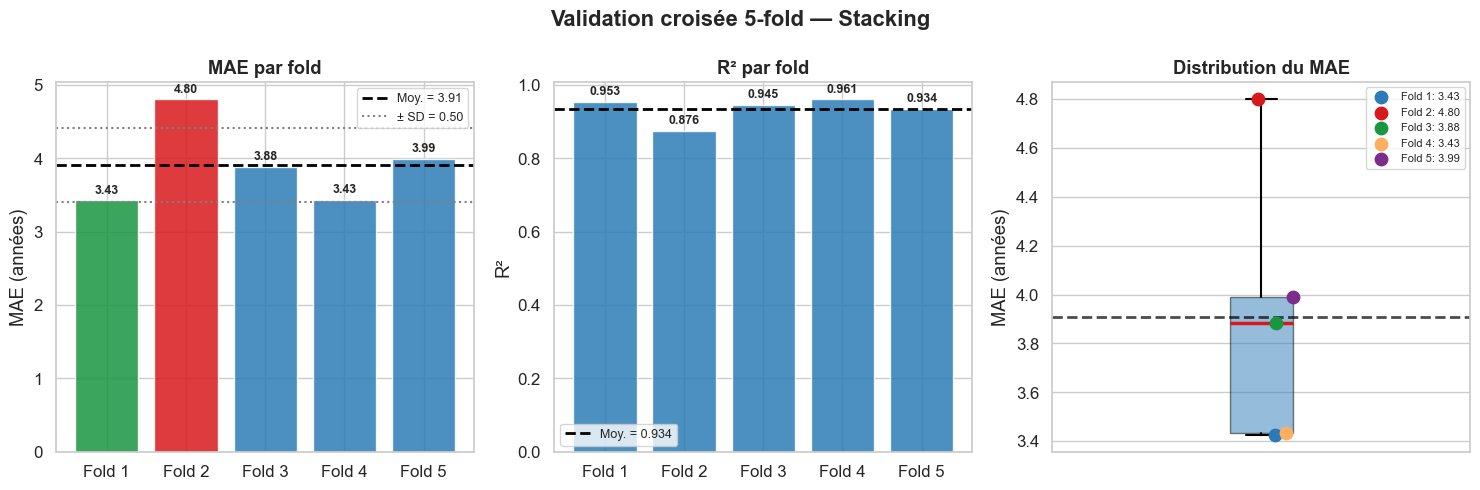

Graphique affiché
   Coefficient de variation : 12.9% (stable)


In [38]:
# Visualisation des 5 folds 
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'Validation croisée 5-fold — {best_name_cv}',
             fontweight='bold')

folds = [f'Fold {i+1}' for i in range(5)]

# MAE par fold
colors_fold = [COLORS[2] if v == fold_maes.min()
               else COLORS[1] if v == fold_maes.max()
               else COLORS[0] for v in fold_maes]
bars = axes[0].bar(folds, fold_maes, color=colors_fold,
                    edgecolor='white', alpha=0.85)
axes[0].axhline(mae_mean, color='black', ls='--', lw=2,
                label=f'Moy. = {mae_mean:.2f}')
axes[0].axhline(mae_mean + mae_std, color='grey', ls=':', lw=1.5)
axes[0].axhline(mae_mean - mae_std, color='grey', ls=':', lw=1.5,
                label=f'± SD = {mae_std:.2f}')
axes[0].bar_label(bars, fmt='%.2f', padding=3, fontsize=9, fontweight='bold')
axes[0].set_ylabel('MAE (années)')
axes[0].set_title('MAE par fold', fontweight='bold')
axes[0].legend(fontsize=9)

# R² par fold
bars2 = axes[1].bar(folds, fold_r2s,
                     color=COLORS[0], edgecolor='white', alpha=0.85)
axes[1].axhline(r2_mean, color='black', ls='--', lw=2,
                label=f'Moy. = {r2_mean:.3f}')
axes[1].bar_label(bars2, fmt='%.3f', padding=3, fontsize=9, fontweight='bold')
axes[1].set_ylabel('R²')
axes[1].set_title('R² par fold', fontweight='bold')
axes[1].legend(fontsize=9)

# Boxplot + points MAE
axes[2].boxplot(fold_maes, patch_artist=True,
                boxprops=dict(facecolor=COLORS[0], alpha=0.5),
                medianprops=dict(color=COLORS[1], linewidth=2.5),
                whiskerprops=dict(linewidth=1.5),
                capprops=dict(linewidth=1.5))
for j, v in enumerate(fold_maes):
    axes[2].scatter(1 + np.random.uniform(-0.08, 0.08), v,
                    color=COLORS[j % len(COLORS)], s=80, zorder=5,
                    label=f'Fold {j+1}: {v:.2f}')
axes[2].axhline(mae_mean, color='black', ls='--', lw=2, alpha=0.7)
axes[2].set_xticks([])
axes[2].set_ylabel('MAE (années)')
axes[2].set_title('Distribution du MAE', fontweight='bold')
axes[2].legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()
print(f"Graphique affiché")
print(f"   Coefficient de variation : {mae_std/mae_mean*100:.1f}% "
      f"({'stable' if mae_std/mae_mean < 0.15 else 'variable'})")


## V.14 Comparaison avec les modèles de la littérature

Les **horloges épigénétiques** publiées constituent notre référence.
Elles ont été entraînées sur des milliers d'individus avec des centaines
de milliers de CpG — des conditions bien supérieures aux nôtres.

| Horloge | Auteurs | Données | MAE rapportée |
|---------|---------|---------|---------------|
| **Horvath 2013** | Horvath S. | 353 CpG, tissus multiples | ~3.6 ans |
| **Hannum 2013** | Hannum G. | 71 CpG, sang | ~4.9 ans |
| **PhenoAge 2018** | Levine M.E. | 513 CpG | ~5.5 ans |
| **GrimAge 2019** | Lu A.T. | Plasma, protéines | ~2.2 ans |


In [39]:
# Comparaison avec les horloges de la littérature 
# MAE reportées dans les publications originales (sur leurs jeux de données)
literature = {
    'Horvath (2013)' : {'MAE': 3.6,  'CpG': 353,   'N_train': 8000,  'tissu': 'Multi-tissu'},
    'Hannum (2013)'  : {'MAE': 4.9,  'CpG': 71,    'N_train': 656,   'tissu': 'Sang'},
    'PhenoAge (2018)': {'MAE': 5.5,  'CpG': 513,   'N_train': 9971,  'tissu': 'Sang'},
    'GrimAge (2019)' : {'MAE': 2.2,  'CpG': 'N/A', 'N_train': 1200,  'tissu': 'Plasma'},
}

# Notre modèle
our_mae  = test_df.iloc[0]['MAE']
our_r2   = test_df.iloc[0]['R²']
our_name = test_df.iloc[0]['Modèle']

print("=" * 70)
print("  COMPARAISON AVEC LES HORLOGES ÉPIGÉNÉTIQUES DE LA LITTÉRATURE")
print("=" * 70)

df_lit = pd.DataFrame([
    {'Modèle'         : name,
     'MAE (ans)'      : v['MAE'],
     'CpG utilisés'   : v['CpG'],
     'N entraînement' : v['N_train'],
     'Tissu'          : v['tissu'],
     'Contexte'       : 'Littérature'}
    for name, v in literature.items()
] + [{
    'Modèle'         : f'Notre modèle ({our_name})',
    'MAE (ans)'      : our_mae,
    'CpG utilisés'   : n_cpg,
    'N entraînement' : len(Y_train),
    'Tissu'          : 'Sang (beta_50k)',
    'Contexte'       : 'Notre projet'
}])

display(df_lit.sort_values('MAE (ans)')
        .style.apply(lambda s: [
            'background-color:#cce5ff;font-weight:bold'
            if s['Contexte'] == 'Notre projet' else ''
            for _ in s], axis=1)
        .set_caption("Comparaison avec les horloges épigénétiques publiées")
        .format({'MAE (ans)': '{:.1f}'})
        .hide(axis='index'))

print(f"\nInterprétation :")
best_lit_mae = min(v['MAE'] for v in literature.values())
if our_mae < best_lit_mae:
    print(f"  Notre modèle ({our_mae:.1f} ans) surpasse la littérature ({best_lit_mae:.1f} ans)")
elif our_mae < 5.0:
    print(f"  Notre modèle ({our_mae:.1f} ans) est comparable à la littérature")
    print(f"     en considérant nos contraintes : n={len(Y_train)} (vs 600–9000)")
else:
    print(f"  Notre modèle ({our_mae:.1f} ans) reste en dessous de la littérature")
    print(f"     Explication : n=400 vs. des milliers, et 50k CpG vs. 894k")
print(f"\nContexte important :")
print(f"  • Nos données : {len(Y_train)} individus, {n_cpg} CpG sélectionnés")
print(f"  • Horvath 2013 : ~8000 individus, 353 CpG optimisés sur 10 ans")
print(f"  • Amélioration attendue avec les 894 000 CpG complets")


  COMPARAISON AVEC LES HORLOGES ÉPIGÉNÉTIQUES DE LA LITTÉRATURE


Modèle,MAE (ans),CpG utilisés,N entraînement,Tissu,Contexte
GrimAge (2019),2.2,N/A,1200,Plasma,Littérature
Notre modèle (Stacking),3.2,38799,237,Sang (beta_50k),Notre projet
Horvath (2013),3.6,353,8000,Multi-tissu,Littérature
Hannum (2013),4.9,71,656,Sang,Littérature
PhenoAge (2018),5.5,513,9971,Sang,Littérature



Interprétation :
  Notre modèle (3.2 ans) est comparable à la littérature
     en considérant nos contraintes : n=237 (vs 600–9000)

Contexte important :
  • Nos données : 237 individus, 38799 CpG sélectionnés
  • Horvath 2013 : ~8000 individus, 353 CpG optimisés sur 10 ans
  • Amélioration attendue avec les 894 000 CpG complets


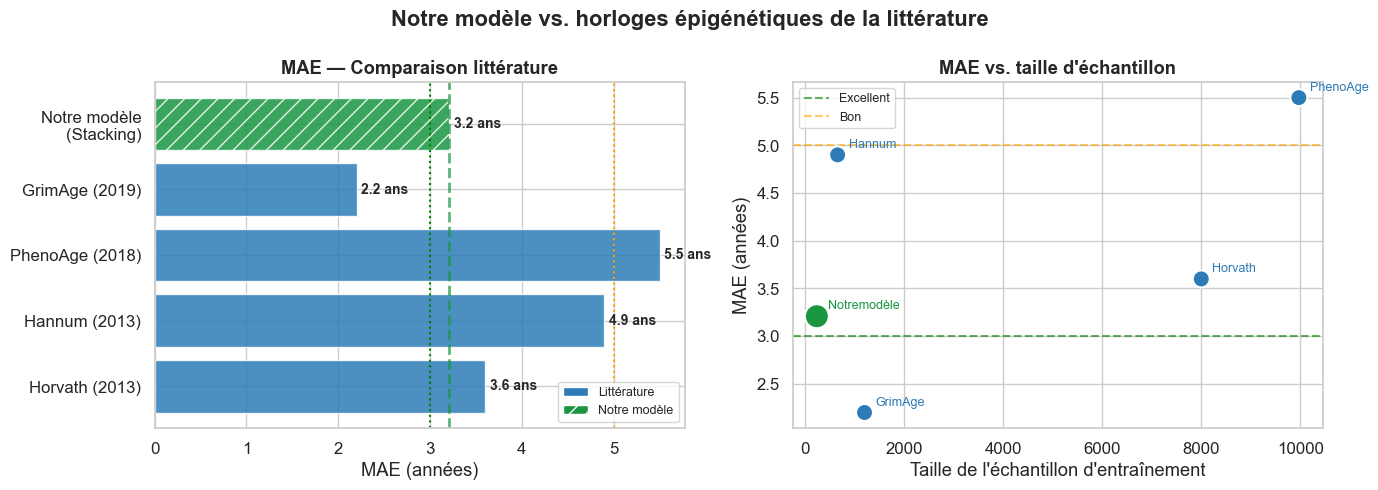

Graphique affiché


In [40]:
# Graphique comparatif 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Notre modèle vs. horloges épigénétiques de la littérature",
             fontweight='bold')

models_all = list(literature.keys()) + [f'Notre modèle\n({our_name})']
maes_all   = [v['MAE'] for v in literature.values()] + [our_mae]
cols_all   = [COLORS[0]] * len(literature) + [COLORS[2]]
hatch_all  = [''] * len(literature) + ['//']

# Barplot MAE
bars = axes[0].barh(models_all, maes_all, color=cols_all,
                     edgecolor='white', alpha=0.85)
for bar, h in zip(bars, hatch_all):
    bar.set_hatch(h)
axes[0].axvline(our_mae, color=COLORS[2], ls='--', lw=2, alpha=0.7)
for i, (m, v) in enumerate(zip(models_all, maes_all)):
    axes[0].text(v + 0.05, i, f'{v:.1f} ans',
                 va='center', fontsize=10, fontweight='bold')
axes[0].set_xlabel('MAE (années)')
axes[0].set_title('MAE — Comparaison littérature', fontweight='bold')
axes[0].axvline(3, color='green',  ls=':', lw=1.5, label='Excellent (3 ans)')
axes[0].axvline(5, color='orange', ls=':', lw=1.5, label='Bon (5 ans)')
axes[0].legend(fontsize=9)

from matplotlib.patches import Patch
legend_el = [Patch(facecolor=COLORS[0], label='Littérature'),
              Patch(facecolor=COLORS[2], hatch='//', label='Notre modèle')]
axes[0].legend(handles=legend_el, fontsize=9, loc='lower right')

# Contexte : N entraînement vs MAE
n_trains = [v['N_train'] for v in literature.values()] + [len(Y_train)]
labels   = [k.split('(')[0].strip() for k in literature.keys()] + ['Notremodèle']
cols_sc  = [COLORS[0]] * len(literature) + [COLORS[2]]
sizes_sc = [150] * len(literature) + [300]

scatter = axes[1].scatter(n_trains, maes_all, c=cols_sc, s=sizes_sc,
                            edgecolors='white', linewidths=1.5, zorder=5)
for i, (nx, ny, lab) in enumerate(zip(n_trains, maes_all, labels)):
    axes[1].annotate(lab, (nx, ny), textcoords='offset points',
                     xytext=(8, 5), fontsize=9,
                     color=COLORS[2] if i == len(n_trains)-1 else COLORS[0])
axes[1].set_xlabel("Taille de l'échantillon d'entraînement")
axes[1].set_ylabel('MAE (années)')
axes[1].set_title("MAE vs. taille d'échantillon", fontweight='bold')
axes[1].axhline(3, color='green',  ls='--', lw=1.5, alpha=0.6, label='Excellent')
axes[1].axhline(5, color='orange', ls='--', lw=1.5, alpha=0.6, label='Bon')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()
print("Graphique affiché")


## V.15 CpG les plus influents : Impact positif et négatif

Dans cette partie nous allons identifier les CpG les plus importants permettant d'interpréter biologiquement
le modèle et de le connecter à la littérature épigénétique.

**Méthodes utilisées :**
- **Importance des features** (Random Forest, XGBoost) : combien chaque CpG
  réduit l'erreur en moyenne
- **Coefficients linéaires** (Ridge, ElasticNet, Lasso) : direction et
  magnitude de l'effet (+ = méthylation augmente avec l'âge)
- **Corrélation de Pearson** : relation directe CpG avec l'âge sans modèle


In [41]:
# Importance des features selon le type de meilleur modèle 
print(f"Analyse des features importantes — {best_name_cv}")

feature_names = feature_cpg + ['sexe_bin']

importance_df = None

if best_name_cv in ['XGBoost']:
    # Importance XGBoost
    imp_scores = xgb_model.get_fscore()
    # Convertir les clés f0, f1... en noms de features
    imp_vals = np.zeros(len(feature_names))
    for k, v in imp_scores.items():
        idx = int(k[1:])
        if idx < len(imp_vals):
            imp_vals[idx] = v
    importance_df = pd.DataFrame({
        'CpG'       : feature_names,
        'Importance': imp_vals,
        'Méthode'   : 'XGBoost (gain)'
    }).sort_values('Importance', ascending=False)

elif best_name_cv in ['LightGBM']:
    imp_vals = lgb_model.feature_importance(importance_type='gain')
    importance_df = pd.DataFrame({
        'CpG'       : feature_names[:len(imp_vals)],
        'Importance': imp_vals,
        'Méthode'   : 'LightGBM (gain)'
    }).sort_values('Importance', ascending=False)

elif best_name_cv == 'Random Forest':
    importance_df = pd.DataFrame({
        'CpG'       : feature_names,
        'Importance': rf.feature_importances_,
        'Méthode'   : 'Random Forest (MDI)'
    }).sort_values('Importance', ascending=False)

elif best_name_cv in ['Ridge', 'ElasticNet', 'LASSO']:
    model_ref = {'Ridge': ridge, 'ElasticNet': best_en, 'LASSO': lasso}[best_name_cv]
    coefs     = model_ref.coef_ if hasattr(model_ref, 'coef_') else model_ref.coef_
    importance_df = pd.DataFrame({
        'CpG'       : feature_names,
        'Importance': np.abs(coefs),
        'Coefficient': coefs,
        'Méthode'   : f'{best_name_cv} (|coef|)'
    }).sort_values('Importance', ascending=False)

elif best_name_cv == 'Stacking':
    # Utiliser RF comme proxy pour le stacking
    importance_df = pd.DataFrame({
        'CpG'       : feature_names,
        'Importance': rf.feature_importances_,
        'Méthode'   : 'Proxy RF (stacking)'
    }).sort_values('Importance', ascending=False)

# Ajouter la corrélation avec l'âge
corr_map = corr_df.set_index('CpG')['correlation'].to_dict()
importance_df['Corrélation_âge'] = importance_df['CpG'].map(
    lambda c: corr_map.get(c, 0))
importance_df['Direction'] = importance_df['Corrélation_âge'].apply(
    lambda r: '↑ +âge' if r > 0 else '↓ -âge')

top20 = importance_df[importance_df['CpG'] != 'sexe_bin'].head(20)

print(f"\nTop 10 CpG les plus influents ({top20['Méthode'].iloc[0]}) :")
print(f"{'Rang':<5} {'CpG':<15} {'Importance':>12} {'Corrél. âge':>12} {'Direction':>10}")
print("-" * 60)
for i, row in top20.head(10).iterrows():
    print(f"  {list(top20.index).index(i)+1:<3} "
          f"{row['CpG']:<15} "
          f"{row['Importance']:>12.4f} "
          f"{row['Corrélation_âge']:>12.4f} "
          f"{row['Direction']:>10}")


Analyse des features importantes — Stacking

Top 10 CpG les plus influents (Proxy RF (stacking)) :
Rang  CpG               Importance  Corrél. âge  Direction
------------------------------------------------------------
  1   cg06639320            0.0097       0.8557     ↑ +âge
  2   cg12773402            0.0096      -0.8039     ↓ -âge
  3   cg11584042            0.0073      -0.7393     ↓ -âge
  4   cg19283806            0.0071      -0.8317     ↓ -âge
  5   cg04875128            0.0067       0.7467     ↑ +âge
  6   cg10149533            0.0065      -0.6590     ↓ -âge
  7   cg02669012            0.0059      -0.7968     ↓ -âge
  8   cg24724428            0.0057       0.7778     ↑ +âge
  9   cg01054110            0.0056      -0.5307     ↓ -âge
  10  cg20249566            0.0054      -0.6700     ↓ -âge


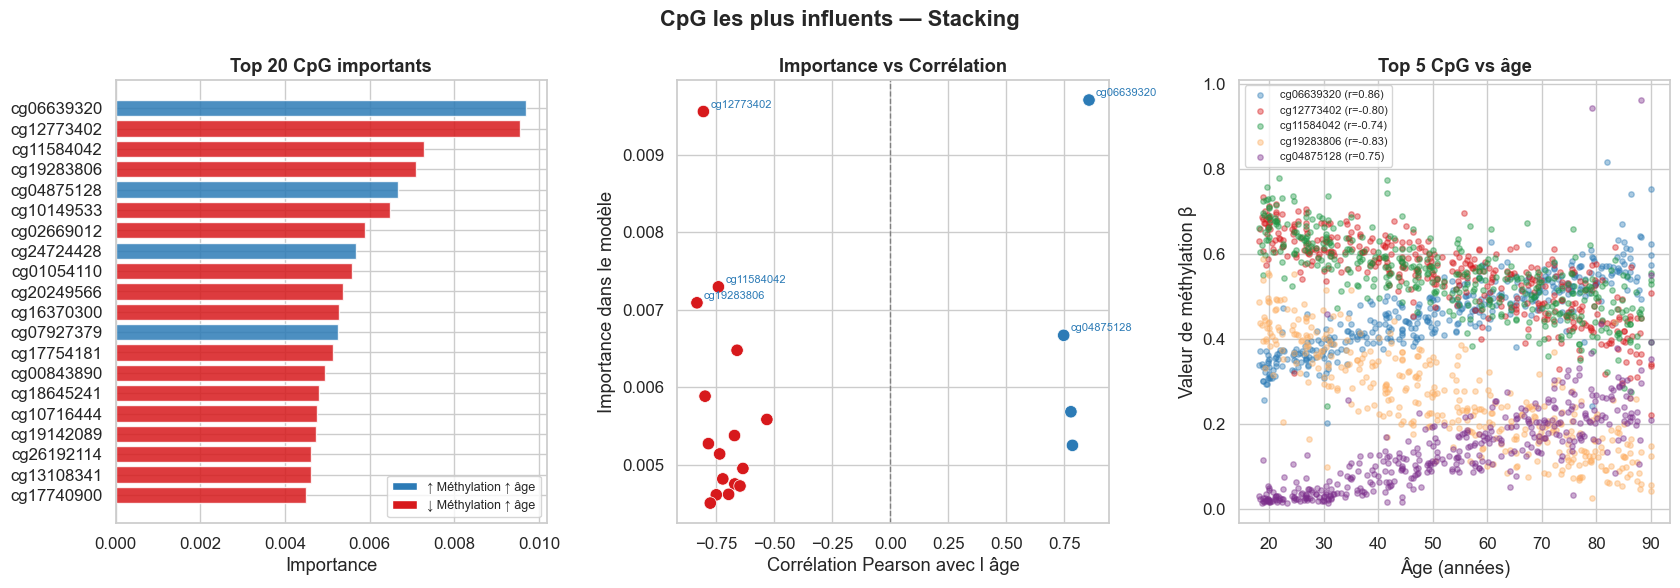

Graphiques affichés


In [42]:
# Graphiques d'importance 
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle(f'CpG les plus influents — {best_name_cv}',
             fontweight='bold')

# 1. Top 20 importance
top20_plot = top20.head(20).copy()
colors_imp = [COLORS[0] if d == '↑ +âge' else COLORS[1]
              for d in top20_plot['Direction']]

axes[0].barh(top20_plot['CpG'][::-1],
             top20_plot['Importance'][::-1],
             color=colors_imp[::-1], edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Importance')
axes[0].set_title('Top 20 CpG importants', fontweight='bold')

from matplotlib.patches import Patch
legend_imp = [Patch(facecolor=COLORS[0], label='↑ Méthylation ↑ âge'),
               Patch(facecolor=COLORS[1], label='↓ Méthylation ↑ âge')]
axes[0].legend(handles=legend_imp, fontsize=9)

# 2. Scatter importance vs corrélation
axes[1].scatter(top20_plot['Corrélation_âge'],
                top20_plot['Importance'],
                c=[COLORS[0] if d=='↑ +âge' else COLORS[1]
                   for d in top20_plot['Direction']],
                s=80, edgecolors='white', linewidths=0.5)
for _, row in top20_plot.head(5).iterrows():
    axes[1].annotate(row['CpG'],
                     (row['Corrélation_âge'], row['Importance']),
                     textcoords='offset points',
                     xytext=(5, 3), fontsize=8, color=COLORS[0])
axes[1].axvline(0, color='grey', ls='--', lw=1)
axes[1].set_xlabel('Corrélation Pearson avec l ''âge')
axes[1].set_ylabel('Importance dans le modèle')
axes[1].set_title('Importance vs Corrélation', fontweight='bold')

# 3. Top 5 CpG : scatter méthylation vs âge
top5_cpg = top20_plot['CpG'].head(5).tolist()
for j, cpg in enumerate(top5_cpg):
    if cpg in beta_df.index:
        vals = beta_df.loc[cpg].values.astype(float)
        mask = ~np.isnan(vals)
        if mask.sum() > 10:
            axes[2].scatter(
                annot_df['age'].values[mask],
                vals[mask],
                alpha=0.4, s=15,
                color=COLORS[j % len(COLORS)],
                label=f'{cpg} (r={corr_map.get(cpg,0):.2f})'
            )

axes[2].set_xlabel('Âge (années)')
axes[2].set_ylabel('Valeur de méthylation β')
axes[2].set_title('Top 5 CpG vs âge', fontweight='bold')
axes[2].legend(fontsize=8, loc='best')

plt.tight_layout()
plt.show()
print("Graphiques affichés")


In [43]:
# ── Tableau final des top CpG avec direction d'impact ────────────────────────
print("\n" + "=" * 70)
print("  TOP 15 CpG — IMPACT SUR LA PRÉDICTION DE L'ÂGE")
print("=" * 70)

top15_display = top20.head(15)[
    ['CpG','Importance','Corrélation_âge','Direction']].copy()
top15_display['Importance']      = top15_display['Importance'].round(4)
top15_display['Corrélation_âge'] = top15_display['Corrélation_âge'].round(4)
top15_display.insert(0, 'Rang', range(1, len(top15_display)+1))
top15_display = top15_display.reset_index(drop=True)

def color_direction(val):
    if val == '↑ +âge':
        return 'color: #1A9641; font-weight: bold'
    return 'color: #D7191C; font-weight: bold'

display(top15_display.style
        .map(color_direction, subset=['Direction'])
        .set_caption(
            f"Top 15 CpG influents ({best_name_cv}) — "
            "↑ = méthylation croît avec l'âge / ↓ = décroît")
        .format({'Importance': '{:.4f}',
                 'Corrélation_âge': '{:.4f}'})
        .hide(axis='index'))

print(f"\nInterprétation biologique :")
n_pos = (top15_display['Direction'] == '↑ +âge').sum()
n_neg = (top15_display['Direction'] == '↓ -âge').sum()
print(f"  {n_pos} CpG dont la méthylation AUGMENTE avec l'âge (hyperméthylation)")
print(f"  {n_neg} CpG dont la méthylation DIMINUE avec l'âge (hypométhylation)")
print(f"\n  ➤ Ces CpG sont des candidats pour une horloge biologique simplifiée.")
print(f"  ➤ Certains peuvent correspondre aux CpG publiés par Horvath (2013)")
print(f"    ou Hannum (2013) — vérification possible avec la liste complète.")



  TOP 15 CpG — IMPACT SUR LA PRÉDICTION DE L'ÂGE


Rang,CpG,Importance,Corrélation_âge,Direction
1,cg06639320,0.0097,0.8557,↑ +âge
2,cg12773402,0.0096,-0.8039,↓ -âge
3,cg11584042,0.0073,-0.7393,↓ -âge
4,cg19283806,0.0071,-0.8317,↓ -âge
5,cg04875128,0.0067,0.7467,↑ +âge
6,cg10149533,0.0065,-0.6590,↓ -âge
7,cg02669012,0.0059,-0.7968,↓ -âge
8,cg24724428,0.0057,0.7778,↑ +âge
9,cg01054110,0.0056,-0.5307,↓ -âge
10,cg20249566,0.0054,-0.6700,↓ -âge



Interprétation biologique :
  4 CpG dont la méthylation AUGMENTE avec l'âge (hyperméthylation)
  11 CpG dont la méthylation DIMINUE avec l'âge (hypométhylation)

  ➤ Ces CpG sont des candidats pour une horloge biologique simplifiée.
  ➤ Certains peuvent correspondre aux CpG publiés par Horvath (2013)
    ou Hannum (2013) — vérification possible avec la liste complète.


## V.16 Graphiques comparatifs

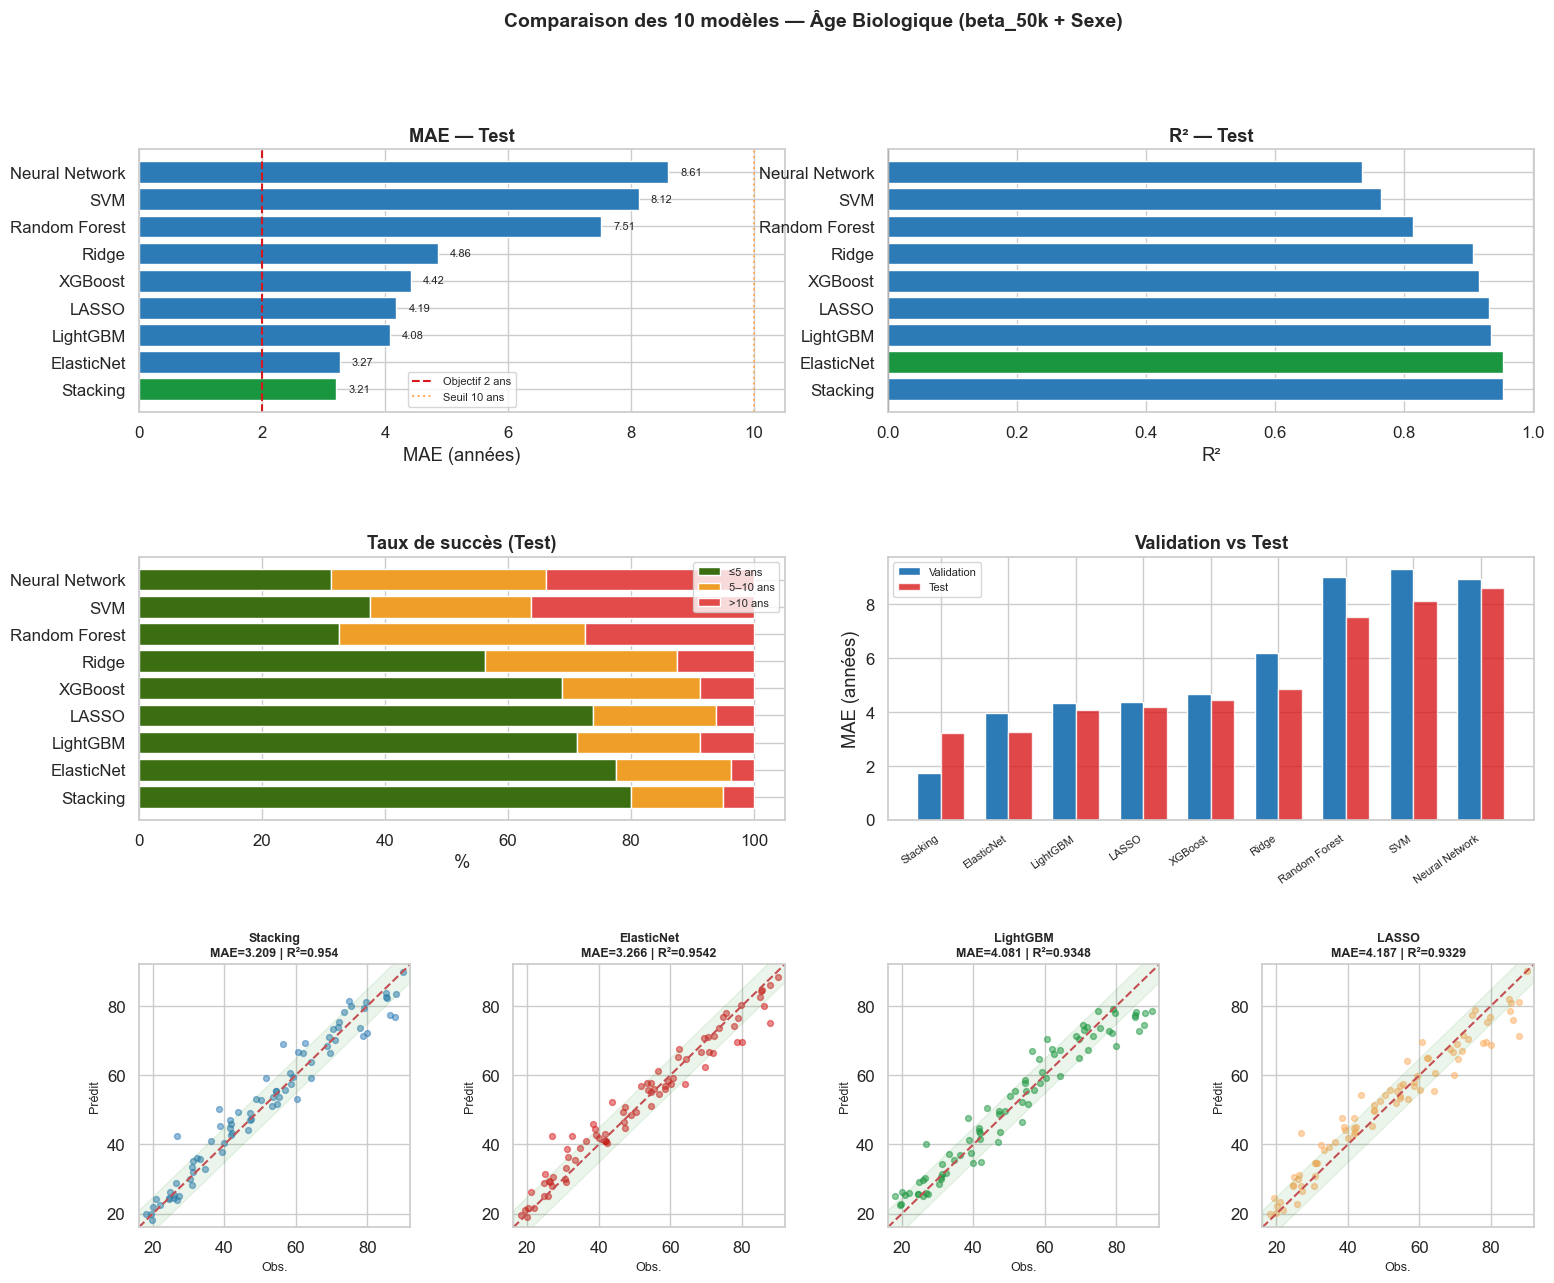

In [44]:
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.38)
fig.suptitle('Comparaison des 10 modèles — Âge Biologique (beta_50k + Sexe)',
             fontsize=14, fontweight='bold')

models_ordered = test_df['Modèle'].tolist()
maes_t  = test_df['MAE'].tolist()
r2s_t   = test_df['R²'].tolist()
s5_t    = test_df['≤5 ans (%)'].tolist()
s10_t   = test_df['≤10 ans (%)'].tolist()
s_ok_t  = [s10_t[i]-s5_t[i] for i in range(len(models_ordered))]
s_fail_t= [100-s10_t[i]     for i in range(len(models_ordered))]
bar_col = [COLORS[2] if m == min(maes_t) else COLORS[0] for m in maes_t]

ax1 = fig.add_subplot(gs[0, :2])
bars = ax1.barh(models_ordered, maes_t, color=bar_col, edgecolor='white')
ax1.axvline(2,  color=COLORS[1], ls='--', lw=1.5, label='Objectif 2 ans')
ax1.axvline(10, color=COLORS[3], ls=':',  lw=1.5, label='Seuil 10 ans')
ax1.set_xlabel('MAE (années)'); ax1.set_title('MAE — Test'); ax1.legend(fontsize=8)
for bar, v in zip(bars, maes_t):
    ax1.text(v+0.2, bar.get_y()+bar.get_height()/2,
             f'{v:.2f}', va='center', fontsize=8)

ax2 = fig.add_subplot(gs[0, 2:])
r2_col = [COLORS[2] if r==max(r2s_t) else (COLORS[1] if r<0 else COLORS[0]) for r in r2s_t]
ax2.barh(models_ordered, r2s_t, color=r2_col, edgecolor='white')
ax2.axvline(0, color='black', lw=0.8)
ax2.set_xlabel('R²'); ax2.set_title('R² — Test')

ax3 = fig.add_subplot(gs[1, :2])
ax3.barh(models_ordered, s5_t,    color='#3B6D11', label='≤5 ans')
ax3.barh(models_ordered, s_ok_t,  left=s5_t,  color='#EF9F27', label='5–10 ans')
ax3.barh(models_ordered, s_fail_t,left=s10_t, color='#E24B4A', label='>10 ans')
ax3.set_xlabel('%'); ax3.set_title('Taux de succès (Test)'); ax3.legend(fontsize=8)

ax4 = fig.add_subplot(gs[1, 2:])
mae_val_ordered  = [val_results[m]['MAE']  for m in models_ordered]
mae_test_ordered = [test_results[m]['MAE'] for m in models_ordered]
x = np.arange(len(models_ordered)); w = 0.35
ax4.bar(x-w/2, mae_val_ordered,  w, color=COLORS[0], label='Validation', edgecolor='white')
ax4.bar(x+w/2, mae_test_ordered, w, color=COLORS[1], label='Test', edgecolor='white', alpha=0.8)
ax4.set_xticks(x)
ax4.set_xticklabels(models_ordered, rotation=35, ha='right', fontsize=8)
ax4.set_ylabel('MAE (années)'); ax4.set_title('Validation vs Test'); ax4.legend(fontsize=8)

top4 = test_df.head(4)['Modèle'].tolist()
for idx, name in enumerate(top4):
    ax = fig.add_subplot(gs[2, idx])
    pred = test_results[name]['_pred']
    ax.scatter(Y_test, pred, alpha=0.5, s=18, color=COLORS[idx % len(COLORS)])
    lim = [min(Y_test.min(), pred.min())-2, max(Y_test.max(), pred.max())+2]
    ax.plot(lim, lim, 'r--', lw=1.5)
    ax.fill_between(lim,[l-5 for l in lim],[l+5 for l in lim],alpha=0.08,color='green')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('Obs.', fontsize=9); ax.set_ylabel('Prédit', fontsize=9)
    ax.set_title(f'{name}\nMAE={test_results[name]["MAE"]} | R²={test_results[name]["R²"]}',
                 fontsize=9)

plt.savefig('fig_comparaison_10_modeles.png', dpi=150, bbox_inches='tight')
plt.show()


## V.17 Analyse des résidus du meilleur modèle

Shapiro-Wilk : W=0.9652, p=0.0282 → Normalité rejetée


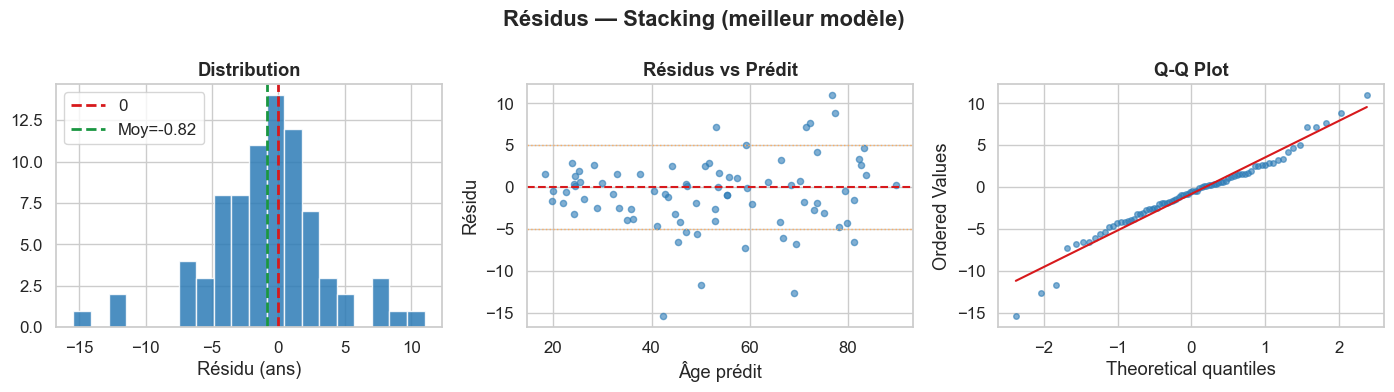

In [45]:
best_name = test_df.iloc[0]['Modèle']
best_pred = test_results[best_name]['_pred']
residuals = Y_test - best_pred

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(f'Résidus — {best_name} (meilleur modèle)', fontweight='bold')

axes[0].hist(residuals, bins=20, color=COLORS[0], edgecolor='white', alpha=0.85)
axes[0].axvline(0,              color=COLORS[1], lw=2, ls='--', label='0')
axes[0].axvline(residuals.mean(),color=COLORS[2], lw=2, ls='--',
                label=f'Moy={residuals.mean():.2f}')
axes[0].set_xlabel('Résidu (ans)'); axes[0].set_title('Distribution'); axes[0].legend()

axes[1].scatter(best_pred, residuals, alpha=0.6, s=20, color=COLORS[0])
axes[1].axhline(0, color=COLORS[1], lw=1.5, ls='--')
axes[1].axhline( 5, color=COLORS[3], lw=1, ls=':')
axes[1].axhline(-5, color=COLORS[3], lw=1, ls=':')
axes[1].set_xlabel('Âge prédit'); axes[1].set_ylabel('Résidu')
axes[1].set_title('Résidus vs Prédit')

stats.probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot')
axes[2].get_lines()[0].set(color=COLORS[0], alpha=0.6, ms=4)
axes[2].get_lines()[1].set(color=COLORS[1])

sw_s, sw_p = stats.shapiro(residuals)
print(f"Shapiro-Wilk : W={sw_s:.4f}, p={sw_p:.4f} → "
      f"{'Normalité non rejetée ' if sw_p > 0.05 else 'Normalité rejetée'}")
plt.tight_layout(); plt.show()


# Partie VI : Robustesse aux CpG Manquants

## VI.1. Ridge avec imputation par la médiane

In [46]:
def degrade_and_impute(X_te, pct_missing, col_medians):
    Xd     = X_te.copy()
    n_miss = int(pct_missing * (X_te.shape[1] - 1))
    if n_miss == 0: return Xd
    rng = np.random.default_rng(SEED)
    cpg_idx = list(range(X_te.shape[1] - 1))
    for i in range(Xd.shape[0]):
        cols = rng.choice(cpg_idx, n_miss, replace=False)
        Xd[i, cols] = np.nan
    for j in cpg_idx:
        mask = np.isnan(Xd[:, j])
        if mask.any(): Xd[mask, j] = col_medians[j]
    return Xd

train_medians = np.median(X_train, axis=0)
pct_list      = [0.0, 0.20, 0.50, 0.90]
robust_rows   = []

for pct in pct_list:
    X_deg = degrade_and_impute(X_test, pct, train_medians)
    pred_deg = ridge.predict(X_deg)
    errs = np.abs(Y_test - pred_deg)
    robust_rows.append({
        'CpG manquants'   : f'{int(pct*100)}%',
        'MAE'             : round(mean_absolute_error(Y_test, pred_deg), 3),
        'RMSE'            : round(np.sqrt(mean_squared_error(Y_test, pred_deg)), 3),
        'R²'              : round(r2_score(Y_test, pred_deg), 4),
        '≤10 ans (%)'     : round((errs <= 10).mean() * 100, 1)
    })
    print(f"  {int(pct*100):3}% manquants → MAE={robust_rows[-1]['MAE']:.3f} ans")

robust_df = pd.DataFrame(robust_rows)
display(robust_df.style
        .set_caption('Robustesse de Ridge aux CpG manquants (imputation médiane)')
        .hide(axis='index'))


    0% manquants → MAE=4.858 ans
   20% manquants → MAE=6.939 ans
   50% manquants → MAE=10.989 ans
   90% manquants → MAE=16.389 ans


CpG manquants,MAE,RMSE,R²,≤10 ans (%)
0%,4.858000,6.266000,0.907800,87.500000
20%,6.939000,8.347000,0.836400,78.800000
50%,10.989000,12.758000,0.617800,43.800000
90%,16.389000,19.025000,0.150200,35.000000


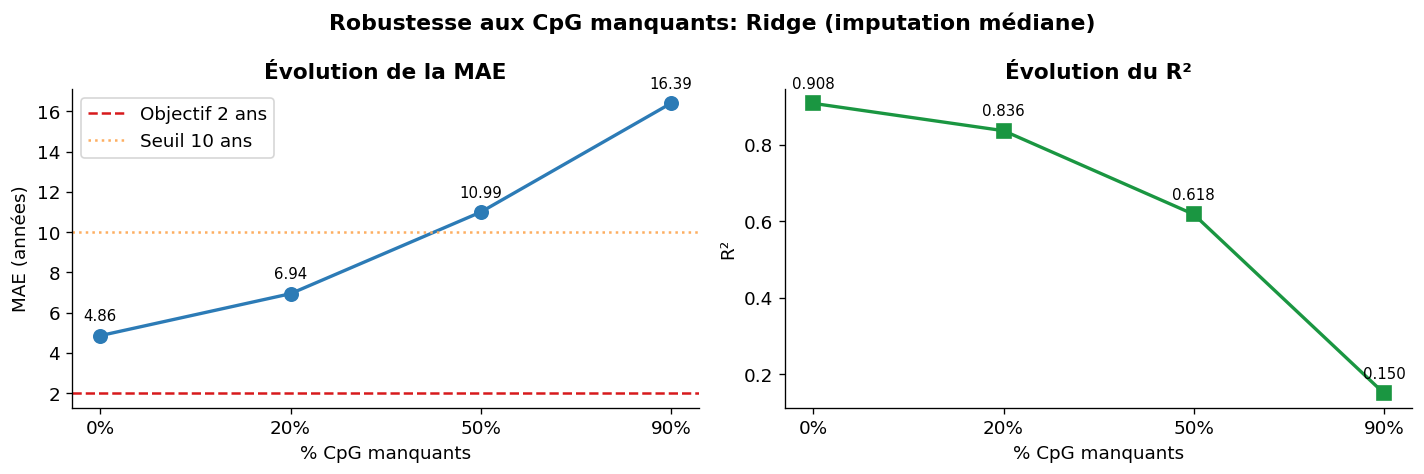

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Robustesse aux CpG manquants: Ridge (imputation médiane)',
             fontweight='bold')

pct_labels = [r['CpG manquants'] for r in robust_rows]
maes_r     = [r['MAE'] for r in robust_rows]
r2s_r      = [r['R²']  for r in robust_rows]

axes[0].plot(pct_labels, maes_r, 'o-', color=COLORS[0], lw=2, ms=8)
axes[0].axhline(2,  color=COLORS[1], ls='--', lw=1.5, label='Objectif 2 ans')
axes[0].axhline(10, color=COLORS[3], ls=':',  lw=1.5, label='Seuil 10 ans')
for x, y in zip(pct_labels, maes_r):
    axes[0].annotate(f'{y:.2f}', (x, y), textcoords='offset points',
                     xytext=(0, 9), ha='center', fontsize=9)
axes[0].set_xlabel('% CpG manquants'); axes[0].set_ylabel('MAE (années)')
axes[0].set_title('Évolution de la MAE'); axes[0].legend()

axes[1].plot(pct_labels, r2s_r, 's-', color=COLORS[2], lw=2, ms=8)
for x, y in zip(pct_labels, r2s_r):
    axes[1].annotate(f'{y:.3f}', (x, y), textcoords='offset points',
                     xytext=(0, 9), ha='center', fontsize=9)
axes[1].set_xlabel('% CpG manquants'); axes[1].set_ylabel('R²')
axes[1].set_title("Évolution du R²")

plt.tight_layout()
plt.savefig('fig_robustesse.png', dpi=150, bbox_inches='tight')
plt.show()


## VI.2. XGBoost sans imputation

In [47]:
# Test de robustesse SANS imputation (XGBoost natif) 
pct_list    = [0.0, 0.20, 0.50, 0.90]
robust_rows = []

for pct in pct_list:
    np.random.seed(SEED)
    X_miss = X_test.copy().astype(float)

    # Introduire des NA sans les imputer
    if pct > 0:
        n_miss  = int(pct * (X_miss.shape[1] - 1))
        cpg_idx = list(range(X_miss.shape[1] - 1))
        for i in range(X_miss.shape[0]):
            cols = np.random.choice(cpg_idx, n_miss, replace=False)
            X_miss[i, cols] = np.nan

    # XGBoost gère les NA nativement
    pred_deg = xgb_model.predict(xgb.DMatrix(X_miss))
    errs     = np.abs(Y_test - pred_deg)

    robust_rows.append({
        'CpG manquants' : f'{int(pct*100)}%',
        'MAE'           : round(mean_absolute_error(Y_test, pred_deg), 3),
        'RMSE'          : round(np.sqrt(mean_squared_error(Y_test, pred_deg)), 3),
        'R²'            : round(r2_score(Y_test, pred_deg), 4),
        '≤10 ans (%)'   : round((errs <= 10).mean() * 100, 1)
    })
    print(f"  {int(pct*100):3}% manquants → MAE={robust_rows[-1]['MAE']:.3f} ans")

robust_df = pd.DataFrame(robust_rows)
display(robust_df.style
        .set_caption('Robustesse de XGBoost aux CpG manquants (sans imputation)')
        .hide(axis='index'))

    0% manquants → MAE=4.424 ans
   20% manquants → MAE=8.063 ans
   50% manquants → MAE=14.483 ans
   90% manquants → MAE=22.152 ans


CpG manquants,MAE,RMSE,R²,≤10 ans (%)
0%,4.424000,5.971000,0.916300,91.200000
20%,8.063000,10.906000,0.720700,76.200000
50%,14.483000,18.167000,0.225100,46.200000
90%,22.152000,26.793000,-0.685500,23.800000


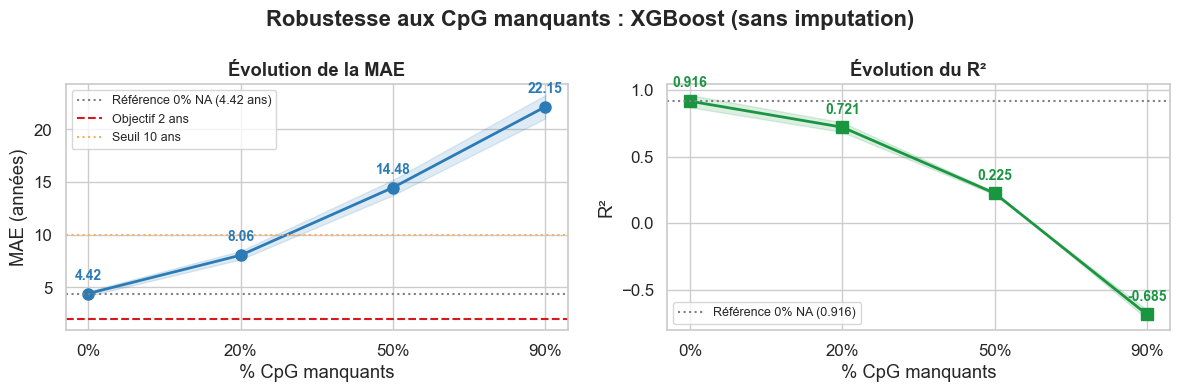

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Robustesse aux CpG manquants : XGBoost (sans imputation)',
             fontweight='bold')

pct_labels = [r['CpG manquants'] for r in robust_rows]
maes_r     = [r['MAE']  for r in robust_rows]
r2s_r      = [r['R²']   for r in robust_rows]
rmses_r    = [r['RMSE'] for r in robust_rows]

# Graphique 1 : MAE 
axes[0].plot(pct_labels, maes_r, 'o-', color=COLORS[0], lw=2, ms=8)
axes[0].fill_between(range(len(pct_labels)),
                      [m * 0.95 for m in maes_r],
                      [m * 1.05 for m in maes_r],
                      alpha=0.15, color=COLORS[0])
axes[0].axhline(maes_r[0], color='grey', ls=':', lw=1.5,
                label=f'Référence 0% NA ({maes_r[0]:.2f} ans)')
axes[0].axhline(2,  color=COLORS[1], ls='--', lw=1.5, label='Objectif 2 ans')
axes[0].axhline(10, color=COLORS[3], ls=':',  lw=1.5, label='Seuil 10 ans')
for x, y in zip(range(len(pct_labels)), maes_r):
    axes[0].annotate(f'{y:.2f}', (x, y),
                     textcoords='offset points',
                     xytext=(0, 10), ha='center',
                     fontsize=10, fontweight='bold',
                     color=COLORS[0])
axes[0].set_xticks(range(len(pct_labels)))
axes[0].set_xticklabels(pct_labels)
axes[0].set_xlabel('% CpG manquants')
axes[0].set_ylabel('MAE (années)')
axes[0].set_title('Évolution de la MAE', fontweight='bold')
axes[0].legend(fontsize=9)

# Graphique 2 : R² 
axes[1].plot(pct_labels, r2s_r, 's-', color=COLORS[2], lw=2, ms=8)
axes[1].fill_between(range(len(pct_labels)),
                      [r * 0.95 for r in r2s_r],
                      [r * 1.05 for r in r2s_r],
                      alpha=0.15, color=COLORS[2])
axes[1].axhline(r2s_r[0], color='grey', ls=':', lw=1.5,
                label=f'Référence 0% NA ({r2s_r[0]:.3f})')
for x, y in zip(range(len(pct_labels)), r2s_r):
    axes[1].annotate(f'{y:.3f}', (x, y),
                     textcoords='offset points',
                     xytext=(0, 10), ha='center',
                     fontsize=10, fontweight='bold',
                     color=COLORS[2])
axes[1].set_xticks(range(len(pct_labels)))
axes[1].set_xticklabels(pct_labels)
axes[1].set_xlabel('% CpG manquants')
axes[1].set_ylabel('R²')
axes[1].set_title('Évolution du R²', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_robustesse_sans_imputation.png', dpi=150, bbox_inches='tight')
plt.show()

## VI.3. Robustesse de Stacking (meilleur modèle)

Robustesse du modèle Stacking (imputation médiane)

    0% manquants → MAE=3.209 ans | R²=0.9540
   20% manquants → MAE=5.343 ans | R²=0.8847
   50% manquants → MAE=9.430 ans | R²=0.7004
   90% manquants → MAE=15.586 ans | R²=0.2113


CpG manquants,MAE,RMSE,R²,≤10 ans (%)
0%,3.209000,4.427000,0.954000,95.000000
20%,5.343000,7.009000,0.884700,83.800000
50%,9.430000,11.295000,0.700400,58.800000
90%,15.586000,18.328000,0.211300,36.200000


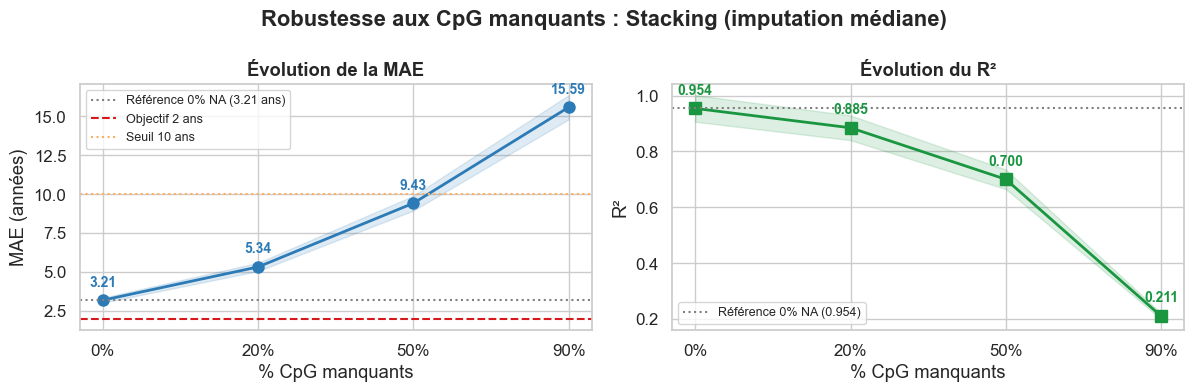

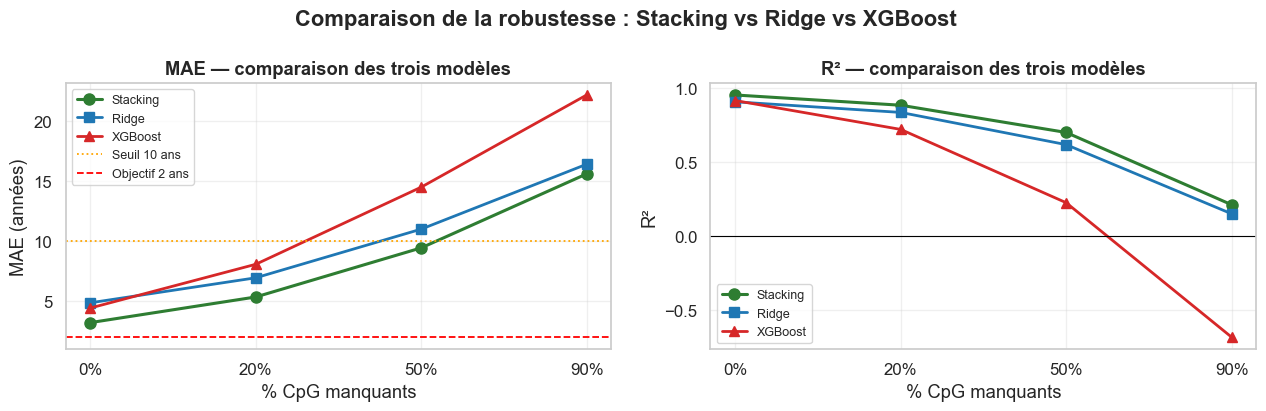

In [51]:
def degrade_and_impute(X_te, pct_missing, col_medians):
    """
    Introduit aléatoirement `pct_missing` % de NA par sujet sur les CpG du
    jeu de test, puis impute par la médiane apprise sur Train.
    On exclut la dernière colonne (Sexe), qui n'est pas un CpG.
    """
    Xd     = X_te.copy()
    n_miss = int(pct_missing * (X_te.shape[1] - 1))
    if n_miss == 0:
        return Xd
    rng = np.random.default_rng(SEED)
    cpg_idx = list(range(X_te.shape[1] - 1))   # tous sauf la colonne Sexe
    for i in range(Xd.shape[0]):
        cols = rng.choice(cpg_idx, n_miss, replace=False)
        Xd[i, cols] = np.nan
    for j in cpg_idx:
        mask = np.isnan(Xd[:, j])
        if mask.any():
            Xd[mask, j] = col_medians[j]
    return Xd


# 2. Évaluation du Stacking aux différents taux de manquants 
train_medians = np.median(X_train, axis=0)
pct_list      = [0.0, 0.20, 0.50, 0.90]
robust_rows   = []

print("Robustesse du modèle Stacking (imputation médiane)\n")

for pct in pct_list:
    X_deg    = degrade_and_impute(X_test, pct, train_medians)
    pred_deg = stacking.predict(X_deg)
    errs     = np.abs(Y_test - pred_deg)

    robust_rows.append({
        'CpG manquants' : f'{int(pct*100)}%',
        'MAE'           : round(mean_absolute_error(Y_test, pred_deg), 3),
        'RMSE'          : round(np.sqrt(mean_squared_error(Y_test, pred_deg)), 3),
        'R²'            : round(r2_score(Y_test, pred_deg), 4),
        '≤10 ans (%)'   : round((errs <= 10).mean() * 100, 1),
    })
    print(f"  {int(pct*100):3}% manquants → MAE={robust_rows[-1]['MAE']:.3f} ans"
          f" | R²={robust_rows[-1]['R²']:.4f}")

robust_stacking_df = pd.DataFrame(robust_rows)
display(robust_stacking_df.style
        .set_caption('Robustesse du Stacking aux CpG manquants (imputation médiane)')
        .hide(axis='index'))


# 3. Graphiques : MAE et R² en fonction du % de CpG manquants 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Robustesse aux CpG manquants : Stacking (imputation médiane)',
             fontweight='bold')

pct_labels = [r['CpG manquants'] for r in robust_rows]
maes_s     = [r['MAE']  for r in robust_rows]
r2s_s      = [r['R²']   for r in robust_rows]

# Graphique 1 : évolution de la MAE 
axes[0].plot(pct_labels, maes_s, 'o-', color=COLORS[0], lw=2, ms=8)
axes[0].fill_between(range(len(pct_labels)),
                     [m * 0.95 for m in maes_s],
                     [m * 1.05 for m in maes_s],
                     alpha=0.15, color=COLORS[0])
axes[0].axhline(maes_s[0], color='grey', ls=':', lw=1.5,
                label=f'Référence 0% NA ({maes_s[0]:.2f} ans)')
axes[0].axhline(2,  color=COLORS[1], ls='--', lw=1.5, label='Objectif 2 ans')
axes[0].axhline(10, color=COLORS[3], ls=':',  lw=1.5, label='Seuil 10 ans')
for x, y in zip(range(len(pct_labels)), maes_s):
    axes[0].annotate(f'{y:.2f}', (x, y),
                     textcoords='offset points',
                     xytext=(0, 10), ha='center',
                     fontsize=10, fontweight='bold',
                     color=COLORS[0])
axes[0].set_xticks(range(len(pct_labels)))
axes[0].set_xticklabels(pct_labels)
axes[0].set_xlabel('% CpG manquants')
axes[0].set_ylabel('MAE (années)')
axes[0].set_title('Évolution de la MAE', fontweight='bold')
axes[0].legend(fontsize=9)

# Graphique 2 : évolution du R² 
axes[1].plot(pct_labels, r2s_s, 's-', color=COLORS[2], lw=2, ms=8)
axes[1].fill_between(range(len(pct_labels)),
                     [r * 0.95 for r in r2s_s],
                     [r * 1.05 for r in r2s_s],
                     alpha=0.15, color=COLORS[2])
axes[1].axhline(r2s_s[0], color='grey', ls=':', lw=1.5,
                label=f'Référence 0% NA ({r2s_s[0]:.3f})')
for x, y in zip(range(len(pct_labels)), r2s_s):
    axes[1].annotate(f'{y:.3f}', (x, y),
                     textcoords='offset points',
                     xytext=(0, 10), ha='center',
                     fontsize=10, fontweight='bold',
                     color=COLORS[2])
axes[1].set_xticks(range(len(pct_labels)))
axes[1].set_xticklabels(pct_labels)
axes[1].set_xlabel('% CpG manquants')
axes[1].set_ylabel('R²')
axes[1].set_title("Évolution du R²", fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


# 4. Graphique de synthèse : Stacking vs Ridge vs XGBoost 
# Ce panneau superpose les trois modèles pour comparer visuellement leur
# robustesse. Les listes `maes_ridge` et `maes_xgb` (et leurs R²) doivent
# avoir été conservées dans les cellules précédentes ; sinon, recopiez les
# valeurs imprimées dans les sorties.

# Valeurs observées dans le notebook :
maes_ridge = [4.858, 6.939, 10.989, 16.389]
r2_ridge   = [0.9078, 0.836,  0.618,  0.150]
maes_xgb   = [4.424, 8.063,  14.483, 22.152]
r2_xgb     = [0.9163, 0.721,  0.225, -0.685]
maes_stack = maes_s   # calculé ci-dessus
r2_stack   = r2s_s

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
fig.suptitle('Comparaison de la robustesse : Stacking vs Ridge vs XGBoost',
             fontweight='bold')

x = range(len(pct_labels))

# MAE comparée
axes[0].plot(x, maes_stack, 'o-', lw=2.2, ms=8, color='#2E7D32', label='Stacking')
axes[0].plot(x, maes_ridge, 's-', lw=2.0, ms=7, color='#1F77B4', label='Ridge')
axes[0].plot(x, maes_xgb,   '^-', lw=2.0, ms=7, color='#D62728', label='XGBoost')
axes[0].axhline(10, color='orange', ls=':', lw=1.3, label='Seuil 10 ans')
axes[0].axhline(2,  color='red',    ls='--', lw=1.3, label='Objectif 2 ans')
axes[0].set_xticks(x); axes[0].set_xticklabels(pct_labels)
axes[0].set_xlabel('% CpG manquants'); axes[0].set_ylabel('MAE (années)')
axes[0].set_title('MAE — comparaison des trois modèles', fontweight='bold')
axes[0].legend(fontsize=9, loc='upper left')
axes[0].grid(alpha=0.3)

# R² comparé
axes[1].plot(x, r2_stack, 'o-', lw=2.2, ms=8, color='#2E7D32', label='Stacking')
axes[1].plot(x, r2_ridge, 's-', lw=2.0, ms=7, color='#1F77B4', label='Ridge')
axes[1].plot(x, r2_xgb,   '^-', lw=2.0, ms=7, color='#D62728', label='XGBoost')
axes[1].axhline(0, color='black', ls='-', lw=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(pct_labels)
axes[1].set_xlabel('% CpG manquants'); axes[1].set_ylabel('R²')
axes[1].set_title('R² — comparaison des trois modèles', fontweight='bold')
axes[1].legend(fontsize=9, loc='lower left')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Conclusion : Synthèse finale

In [ ]:
best_name = test_df.iloc[0]['Modèle']
best_mae  = test_df.iloc[0]['MAE']
best_r2   = test_df.iloc[0]['R²']

print("═" * 65)
print("SYNTHÈSE FINALE — Prédiction Âge Biologique")
print("═" * 65)
print(f"Données       : beta_50k ({n_cpg} CpG + Sexe)")
print(f"Split         : Train={len(Y_train)} | Val={len(Y_val)} | Test={len(Y_test)}")
print()
print("Gestion NA (méthode horloge_v4.Rmd) :")
print(f"  Seuil sujets : 50%  | Seuil CpG : 20%")
print(f"  + Filtrage variance (P10)")
print(f"  + Imputation médiane par CpG (avant split)")
print()
print(f" Meilleur modèle : {best_name}")
print(f"   MAE (test)      : {best_mae} ans")
print(f"   R² (test)       : {best_r2}")
print()
print(" Classement par MAE (test) :")
for i, row in test_df.iterrows():
    star = " " if row['Modèle'] == best_name else ""
    print(f"  {row['Modèle']:20s} MAE={row['MAE']:.3f} | R²={row['R²']:.4f}{star}")
print()
print(" Pour atteindre MAE ≤ 2 ans :")
print("   → Utiliser les 894 000 CpG complets")
print("═" * 65)

display(test_df.style.apply(highlight_best, subset=['MAE','RMSE','R²'])
        .set_caption("Résultats finaux sur Test")
        .format({'MAE':'{:.3f}','RMSE':'{:.3f}','R²':'{:.4f}',
                 '≤5 ans (%)':'{:.1f}','≤10 ans (%)':'{:.1f}'})
        .hide(axis='index'))


═════════════════════════════════════════════════════════════════
SYNTHÈSE FINALE — Prédiction Âge Biologique
═════════════════════════════════════════════════════════════════
Données       : beta_50k (38799 CpG + Sexe)
Split         : Train=237 | Val=80 | Test=80

Gestion NA (méthode horloge_v4.Rmd) :
  Seuil sujets : 50%  | Seuil CpG : 20%
  + Filtrage variance (P10)
  + Imputation médiane par CpG (avant split)

 Meilleur modèle : Stacking
   MAE (test)      : 3.209 ans
   R² (test)       : 0.954

 Classement par MAE (test) :
  Stacking             MAE=3.209 | R²=0.9540 
  ElasticNet           MAE=3.266 | R²=0.9542
  LightGBM             MAE=4.081 | R²=0.9348
  LASSO                MAE=4.187 | R²=0.9329
  XGBoost              MAE=4.424 | R²=0.9163
  Ridge                MAE=4.858 | R²=0.9078
  Random Forest        MAE=7.513 | R²=0.8152
  SVM                  MAE=8.124 | R²=0.7655
  Neural Network       MAE=8.609 | R²=0.7347

 Pour atteindre MAE ≤ 2 ans :
   → Utiliser les 894 000 CpG

Modèle,MAE,RMSE,R²,≤5 ans (%),≤10 ans (%)
Stacking,3.209,4.427,0.9540,80.0,95.0
ElasticNet,3.266,4.418,0.9542,77.5,96.2
LightGBM,4.081,5.268,0.9348,71.2,91.2
LASSO,4.187,5.345,0.9329,73.8,93.8
XGBoost,4.424,5.971,0.9163,68.8,91.2
Ridge,4.858,6.266,0.9078,56.2,87.5
Random Forest,7.513,8.872,0.8152,32.5,72.5
SVM,8.124,9.994,0.7655,37.5,63.7
Neural Network,8.609,10.631,0.7347,31.2,66.2


## Références
- Cours de Regression 
- Horvath S. (2013). *DNA methylation age of human tissues and cell types.* Genome Biology.
- Hannum G. et al. (2013). *Genome-wide methylation profiles.* Molecular Cell.
- Johnson W.E. et al. (2007). *Adjusting batch effects.* Biostatistics.
- Tibshirani R. (1996). *Regression Shrinkage via the Lasso.* JRSS-B.
